In [136]:
import pandas as pd
from pandas.plotting import lag_plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import kstest_normal
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.api import (het_breuschpagan, het_goldfeldquandt, het_white, het_arch)
from statsmodels.stats.diagnostic import (acorr_breusch_godfrey, acorr_ljungbox, acorr_lm)
import statsmodels.api as sm
import scipy
from scipy.stats import stats
from scipy.stats import shapiro, kstest, normaltest
from scipy.signal import periodogram
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.cblof import CBLOF
from pyod.models.iforest import IForest
from pyod.models.copod import COPOD
from pyod.models.mad import MAD
from pyod.models.ocsvm import OCSVM
from joblib import dump, load
# from pycaret.anomaly import *
from sklearn.ensemble import IsolationForest


from pathlib import Path
import warnings

warnings.simplefilter('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'

In [2]:
path = Path('/home/jeremy/Documents')

transaction = pd.read_excel(path / 'Transactions.xlsx')
transaction['Transaction_Date'] = transaction['Transaction Date']
cols = ['Amount', 'Transaction_Date']
transaction_df = transaction[cols]
# transaction = transaction.drop(columns='Transaction Date')
transaction.head()

,Trace ID,Posting Date,Account No,Description,Amount,Posting S,Posted,Account Name,Unit ID,Transaction Type,...,Entry No,Transaction Type Charges,Card Acceptor Terminal ID,ATM Card No,Customer Names,Process Code,Reference No,Is Coop Bank,POS Vendor,Transaction_Date
0,USSD-98209269-152052,2025-01-24,0101-005423900,USSD Withdrawal,3022.4,NaN,0,HABOYA TEI MKO,M-PESA,Withdrawal,...,3616322,Balance Enquiry,NaN,254795321709,NaN,NaN,NaN,0,ATM Lobby,2025-01-24
1,USSD-662078485-60422,2025-01-22,0109-007815700,USSD Withdrawal,2922.4,NaN,0,ERICK MUNGA,M-PESA,Withdrawal,...,3613622,Balance Enquiry,NaN,254702307923,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
2,USSD-716572205-64135,2025-01-22,0101-017171700,USSD Withdrawal,4022.4,NaN,0,OMAR MAKORANI WACHU,M-PESA,Withdrawal,...,3613352,Balance Enquiry,NaN,254729501490,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
3,USSD-715659342-85289,2025-01-22,0101-014659300,USSD Withdrawal,4022.4,NaN,0,STANLEY BARSIBOI CHEPKIRWOK,M-PESA,Withdrawal,...,3613210,Balance Enquiry,NaN,254722660045,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
4,USSD-709957019-43649,2025-01-21,0101-021174300,USSD Withdrawal,2022.4,NaN,0,TIMAMU MWARAVINO CHEMBE,M-PESA,Withdrawal,...,3612562,Balance Enquiry,NaN,254112168233,NaN,NaN,NaN,0,ATM Lobby,2025-01-21


In [3]:
# transaction_df['Amount_Int'] = transaction_df['Amount'].astype(int)

In [4]:
transaction_df.head()

,Amount,Transaction_Date
0,3022.4,2025-01-24
1,2922.4,2025-01-22
2,4022.4,2025-01-22
3,4022.4,2025-01-22
4,2022.4,2025-01-21


In [5]:
# transaction_df.columns = transaction_df.columns.str.strip()
transaction_df['Transaction_Date'] = pd.to_datetime(transaction_df['Transaction_Date'])
transaction_df = transaction_df.set_index('Transaction_Date')
# transaction_df['Amount'] = pd.to_numeric(
#     transaction_df['Amount'].str.replace(',', ''), errors='coerce'
# )
transaction_df.head()

,Amount
Transaction_Date,
2025-01-24,3022.4
2025-01-22,2922.4
2025-01-22,4022.4
2025-01-22,4022.4
2025-01-21,2022.4


<Axes: xlabel='Transaction_Date'>

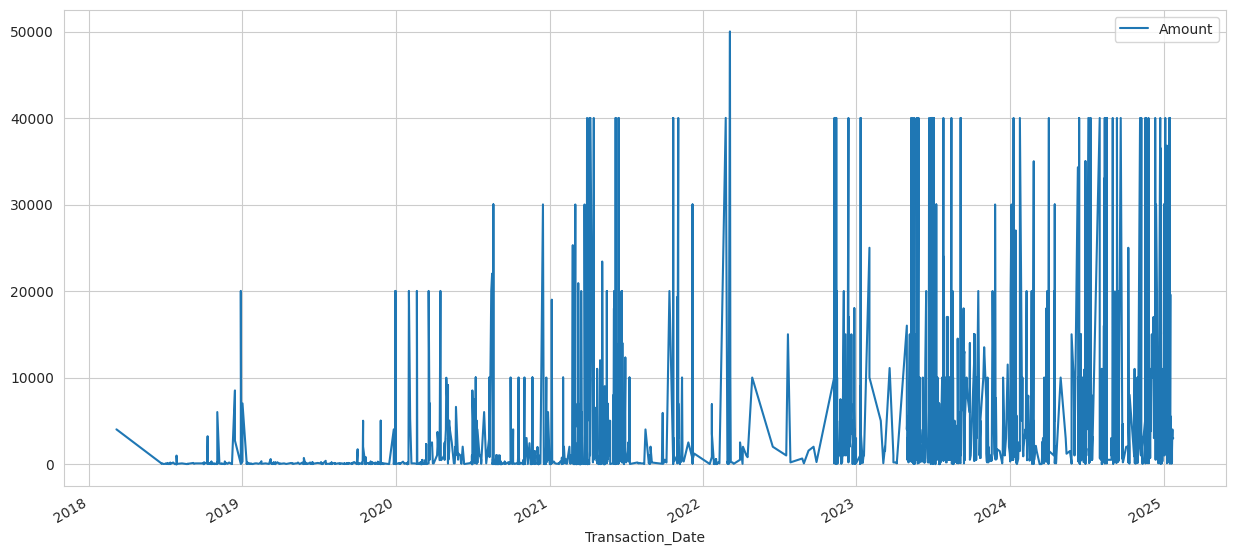

In [6]:
transaction_df.plot(figsize=(15,7))

In [7]:
transaction_df.isna().sum()

Amount    0
dtype: int64

In [38]:
# create plot_outliers function that will be used later in the recipes
def plot_outliers(outliers, df, method='KNN', halignment='right', valignment='bottom', labels=False):
    '''
    outliers: these are the known outliers dates like holidays
    df: dataframe to check and plot the outliers
    '''
    
    ax = df.plot(alpha=.6)

    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'rx', markersize=8, markerfacecolor='none', markeredgecolor='k')
            plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        df.loc[outliers.index].plot(ax=ax, style='rx')

    plt.title(f'Transactions - {method}')
    plt.xlabel('date'); plt.ylabel('Number of Transactions')
    plt.legend(['transactions', 'outliers'])
    plt.show()

In [9]:
transaction_df = transaction_df.resample('21D').mean()

transaction_df.head()

,Amount
Transaction_Date,
2018-03-07,4032.0
2018-03-28,NaN
2018-04-18,NaN
2018-05-09,NaN
2018-05-30,NaN


In [10]:
transaction_df.isna().sum()

Amount    7
dtype: int64

In [11]:
transaction_dates = ['2022-04-27','2023-01-25','2024-12-18']

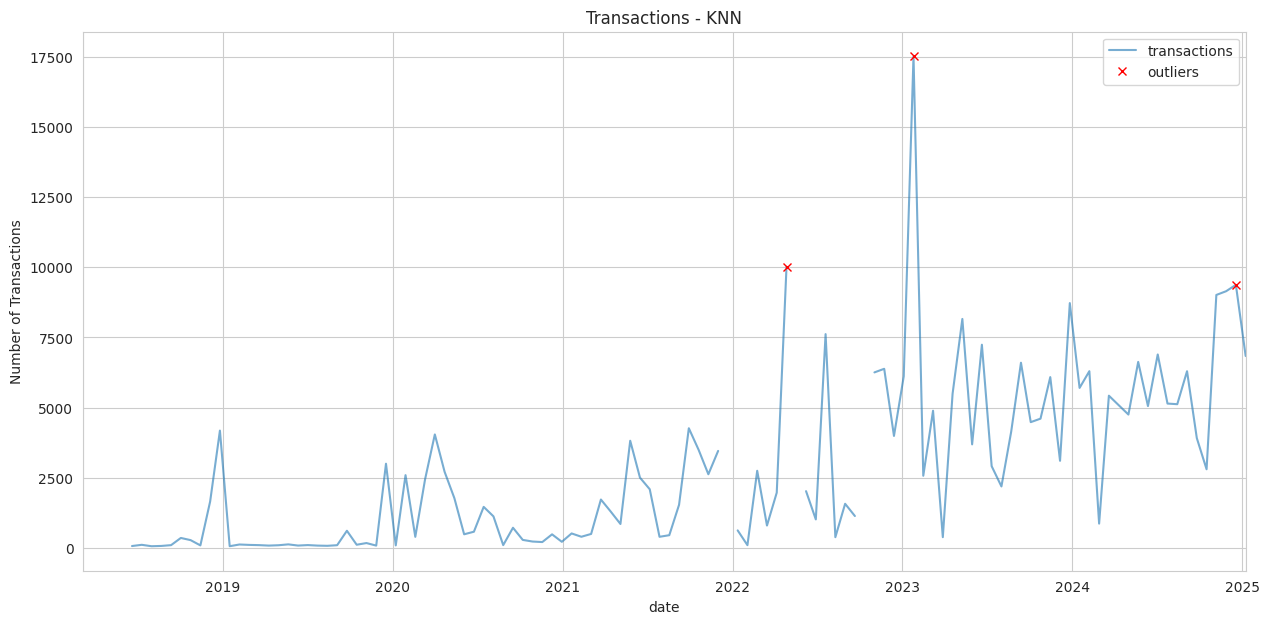

In [39]:
known_outliers = transaction_df.loc[transaction_dates]
plot_outliers(known_outliers, transaction_df, 'KNN')

<Axes: ylabel='Count'>

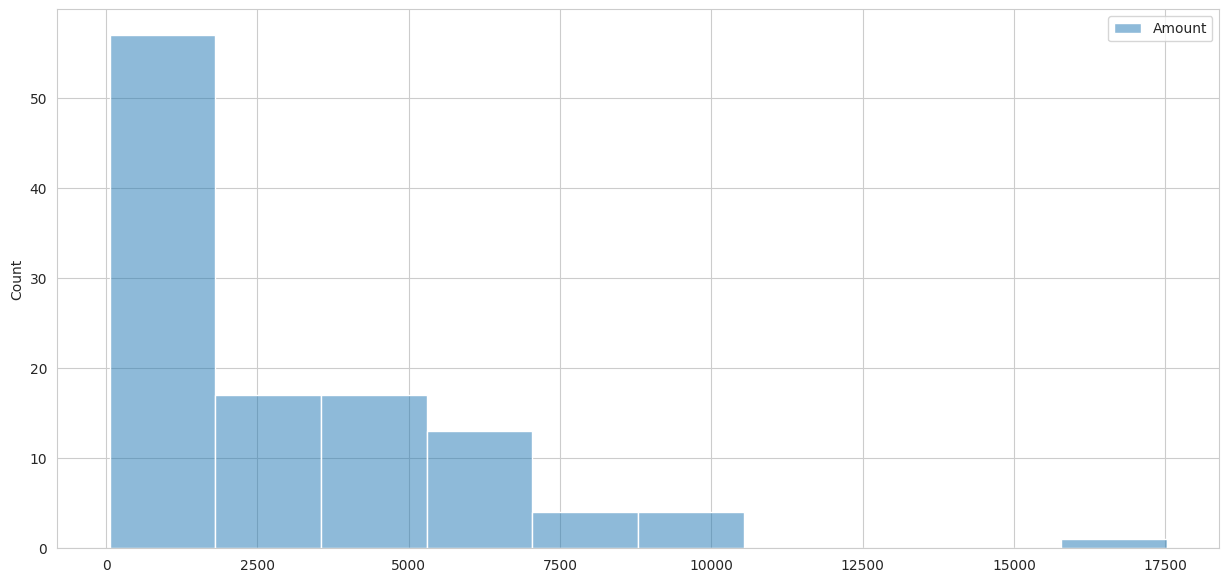

In [40]:
sns.histplot(transaction_df)

<Axes: xlabel='Transaction_Date'>

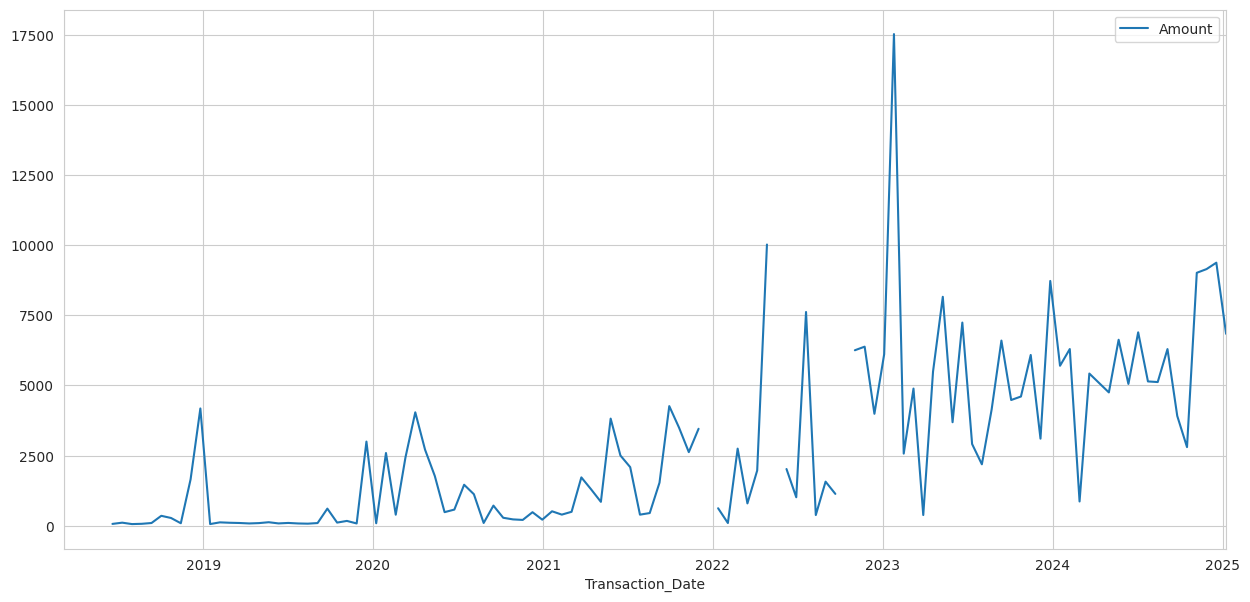

In [41]:
transaction_df.plot()

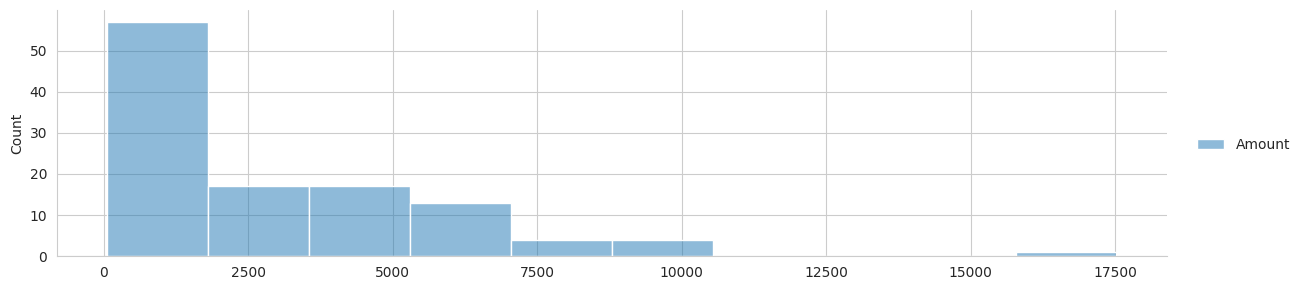

In [42]:
sns.displot(transaction_df, height=3, kind='hist', aspect=4)

<Axes: ylabel='Amount'>

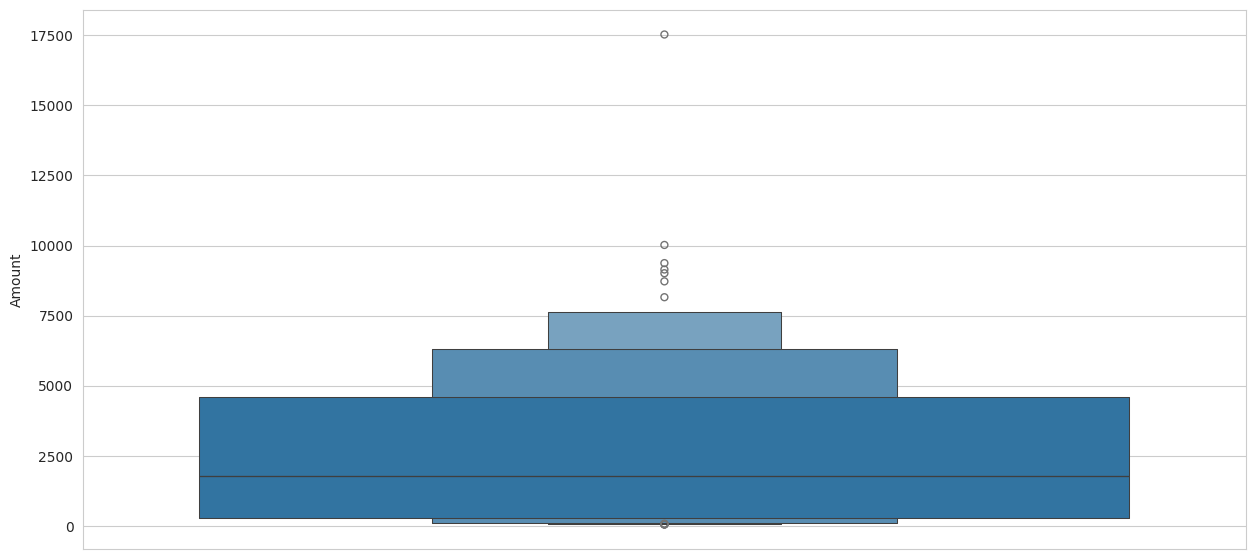

In [43]:
sns.boxenplot(transaction_df['Amount'])

You can filter the outliers in the box plot above by extracting amount greater than 7500.

<Axes: ylabel='Amount'>

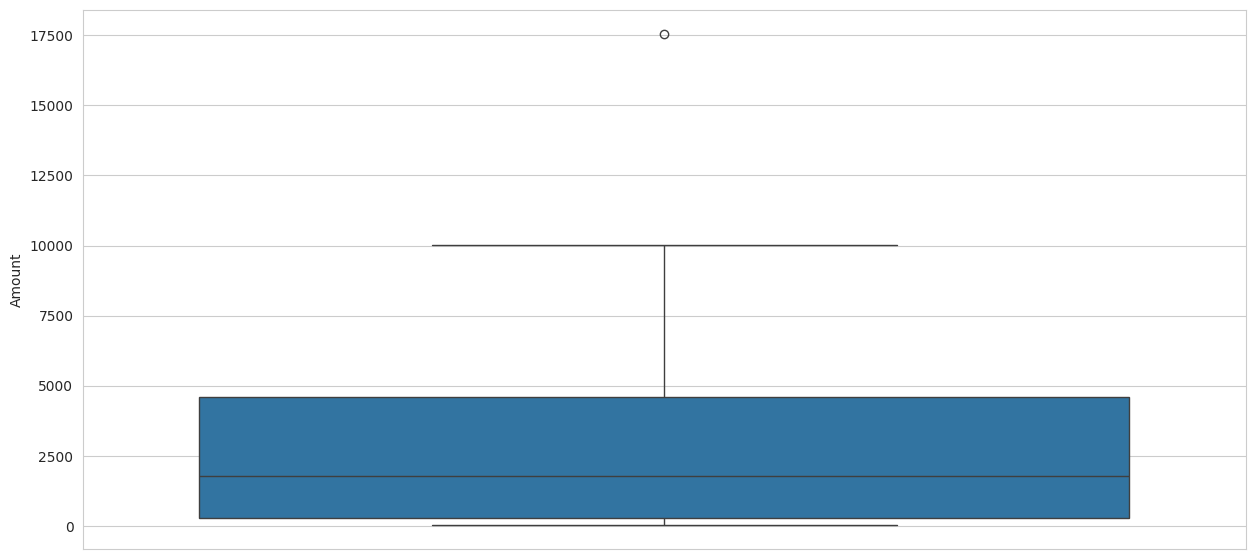

In [44]:
sns.boxplot(transaction_df['Amount'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

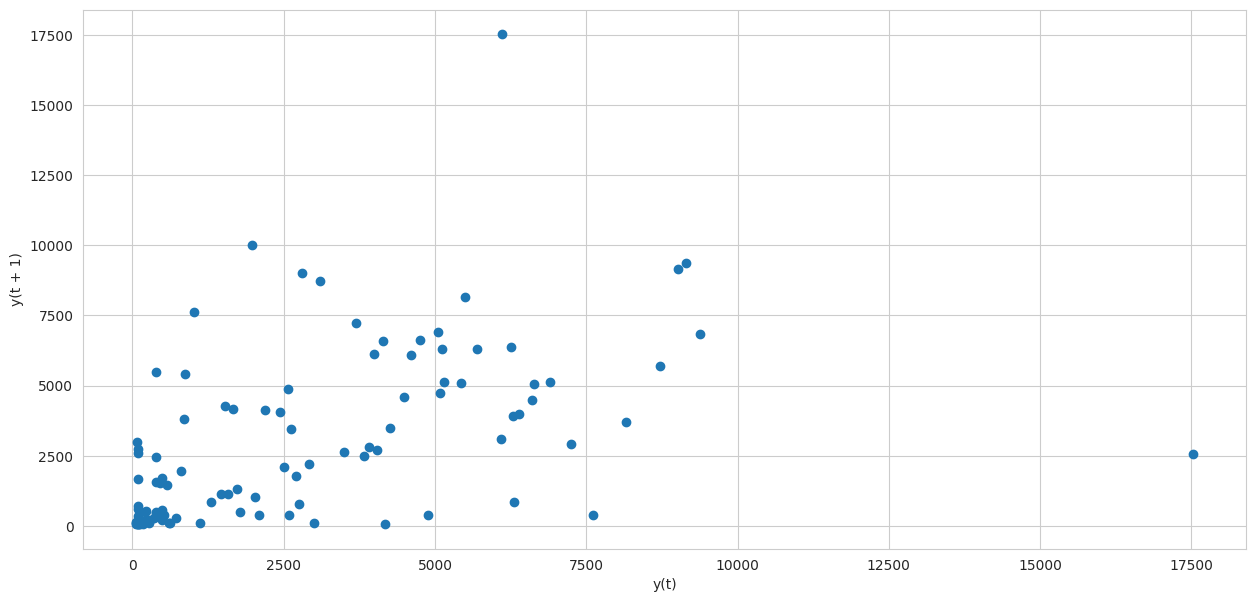

In [45]:
lag_plot(transaction_df)

It shows there is an autocorrelation between the values i.e future (predicted) values and previous values are correlated with each other.

In [19]:
#  Determine the outliers using Turkey fences
percentiles = [0, .05, .1, .25, .5, .75, .90, .95, 1]

transaction_df.describe(percentiles=percentiles)

,Amount
count,113.000000
mean,2795.354370
std,3026.593968
min,60.000000
0%,60.000000
5%,82.100000
10%,95.294118
25%,285.288889
50%,1773.125000
75%,4606.170909


In [20]:
def iqr_outliers(df, column_name):
    data = df[column_name]

    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    return df[(data < lower_fence) | (data > upper_fence)]

In [21]:
outliers = iqr_outliers(transaction_df, 'Amount')
outliers

,Amount
Transaction_Date,


In [23]:
scipy.stats.norm.ppf(0.75)         # normalization factor used in the formula

0.6744897501960817

In [27]:
def modified_z_score(df, degree=3):
    data = df.copy()
    s = scipy.stats.norm.ppf(0.75)
    numerator = s * (data - data.median())
    MAD = np.abs(data - data.median()).median()
    data['modified_zscore'] = numerator / MAD
    outliers = data[(data['modified_zscore'] > degree) | (data['modified_zscore'] < -degree)]

    return outliers['Amount'], data

array([[<Axes: title={'center': 'Amount'}>,
        <Axes: title={'center': 'modified_zscore'}>]], dtype=object)

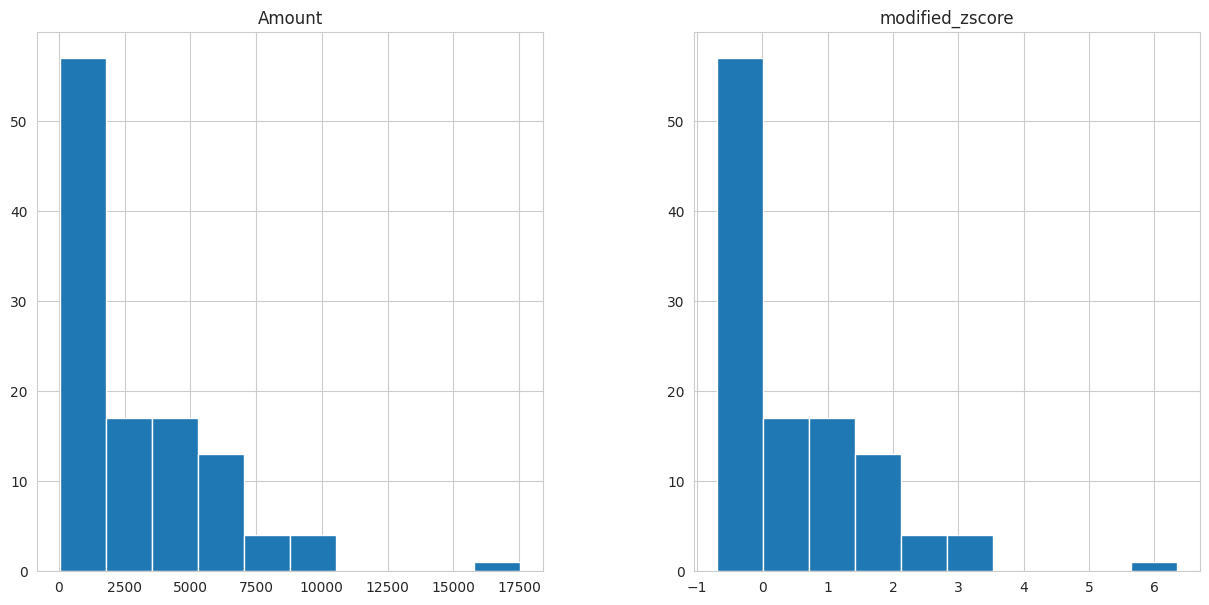

In [28]:
threshold = 3
outliers, transformed_data = modified_z_score(transaction_df, threshold)

transformed_data.hist()

In [29]:
outliers

Transaction_Date
2022-04-27    10022.400000
2023-01-25    17522.400000
2024-12-18     9375.458621
Name: Amount, dtype: float64

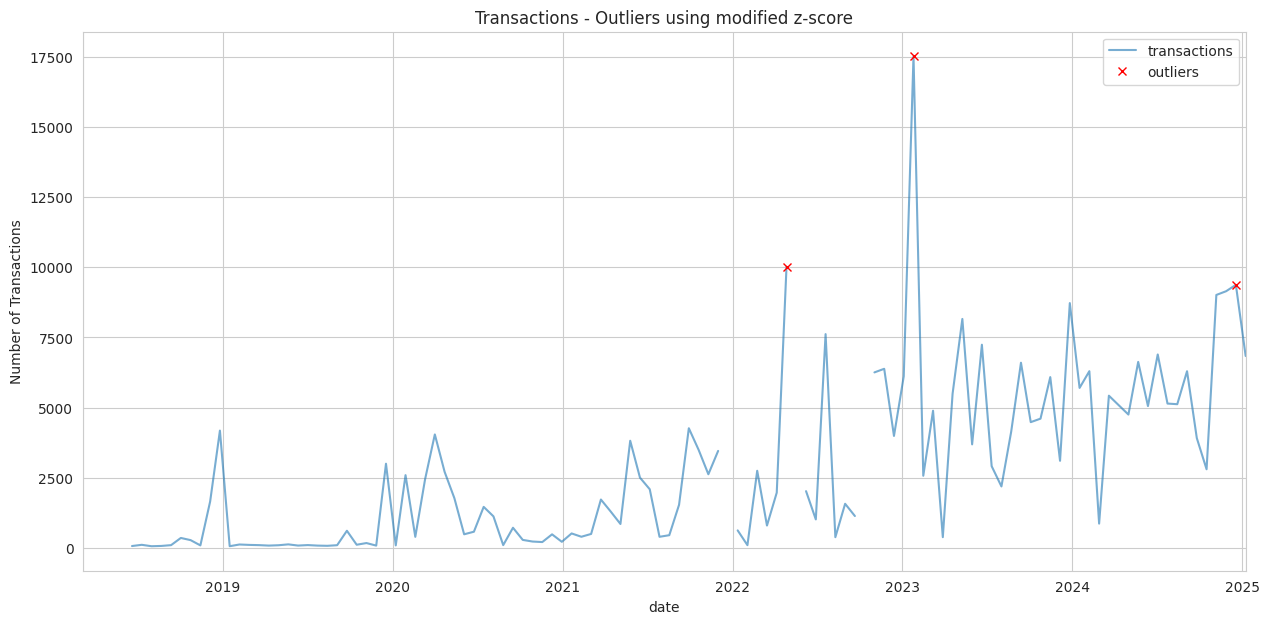

In [30]:
plot_outliers(outliers, transaction_df, "Outliers using modified z-score")

In [31]:
def plot_modified_zscore(df, degree=3):
    n = len(df)

    plt.figure(figsize=(8,8))
    plt.plot(df, 'k^')
    plt.plot([0,n],[degree,degree],'r--')
    plt.plot([0,n],[-degree,-degree],'r--')
    plt.show()

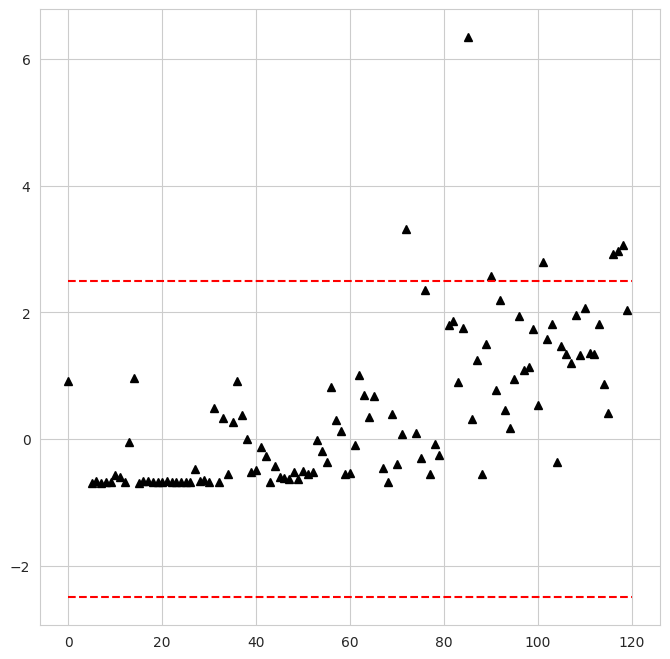

In [32]:
data = transformed_data['modified_zscore'].values
plot_modified_zscore(data, degree=2.5)

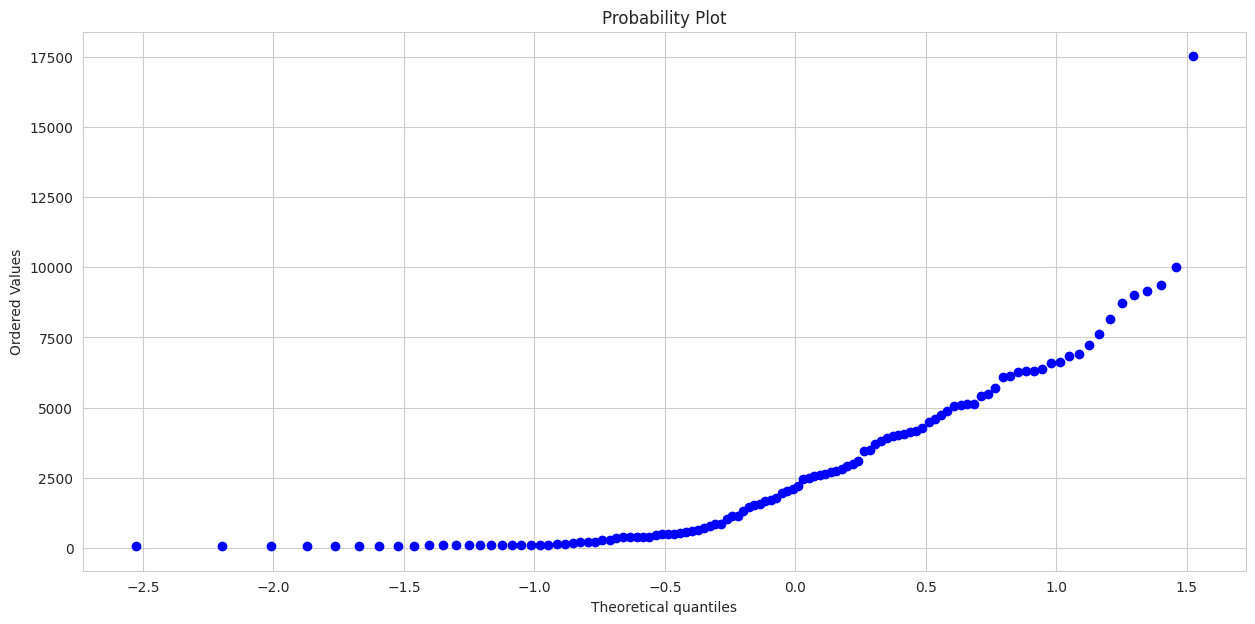

In [33]:
res = scipy.stats.probplot(transaction_df.values.reshape(-1), plot=plt)

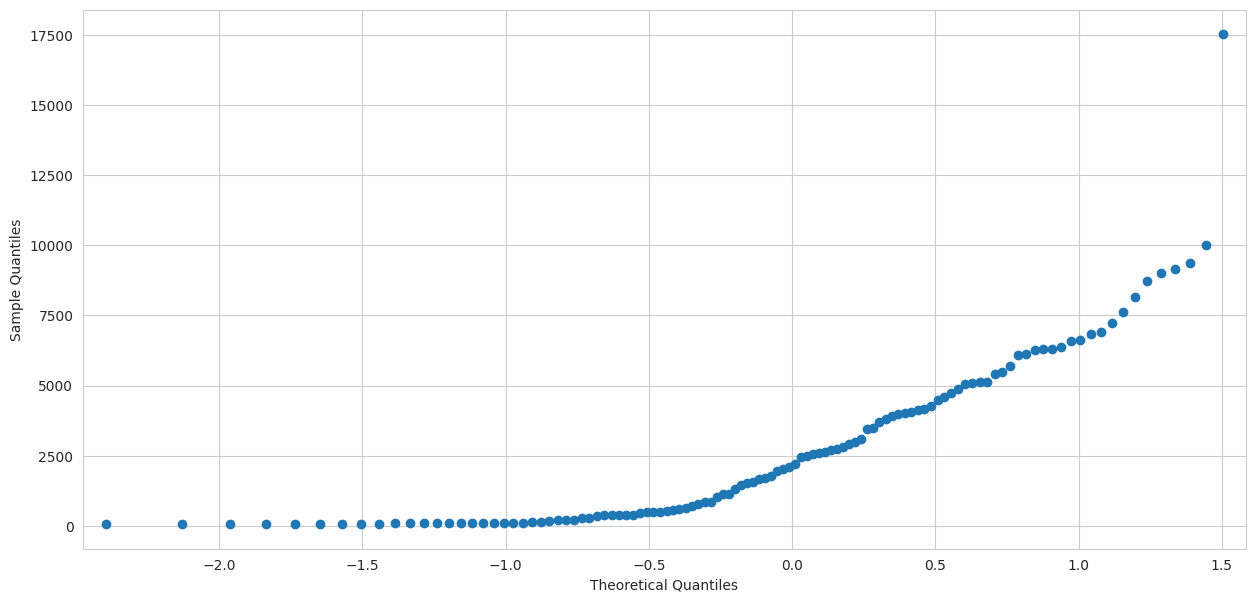

In [34]:
qqplot(transaction_df.values.reshape(-1), line='s')
plt.show()

### Outlier detection using unsupervised ml

In [47]:
knn = KNN(contamination=0.03, method='mean', n_neighbors=10)
transaction_df = transaction_df.ffill()
knn.fit(transaction_df)

KNN(algorithm='auto', contamination=0.03, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=10, p=2,
  radius=1.0)

In [49]:
predicted = pd.Series(knn.predict(transaction_df), index=transaction_df.index)
print('Total number of outliers = ', predicted.sum())

Total number of outliers =  3


In [50]:
predicted

Transaction_Date
2018-03-07    0
2018-03-28    0
2018-04-18    0
2018-05-09    0
2018-05-30    0
             ..
2024-10-16    0
2024-11-06    0
2024-11-27    0
2024-12-18    0
2025-01-08    0
Freq: 21D, Length: 120, dtype: int64

In [52]:
outliers = predicted[predicted == 1]
outliers = transaction_df.loc[outliers.index]
outliers

,Amount
Transaction_Date,
2022-04-27,10022.4
2022-05-18,10022.4
2023-01-25,17522.4


We still have got 3 outliers by using k nearest neighbors.

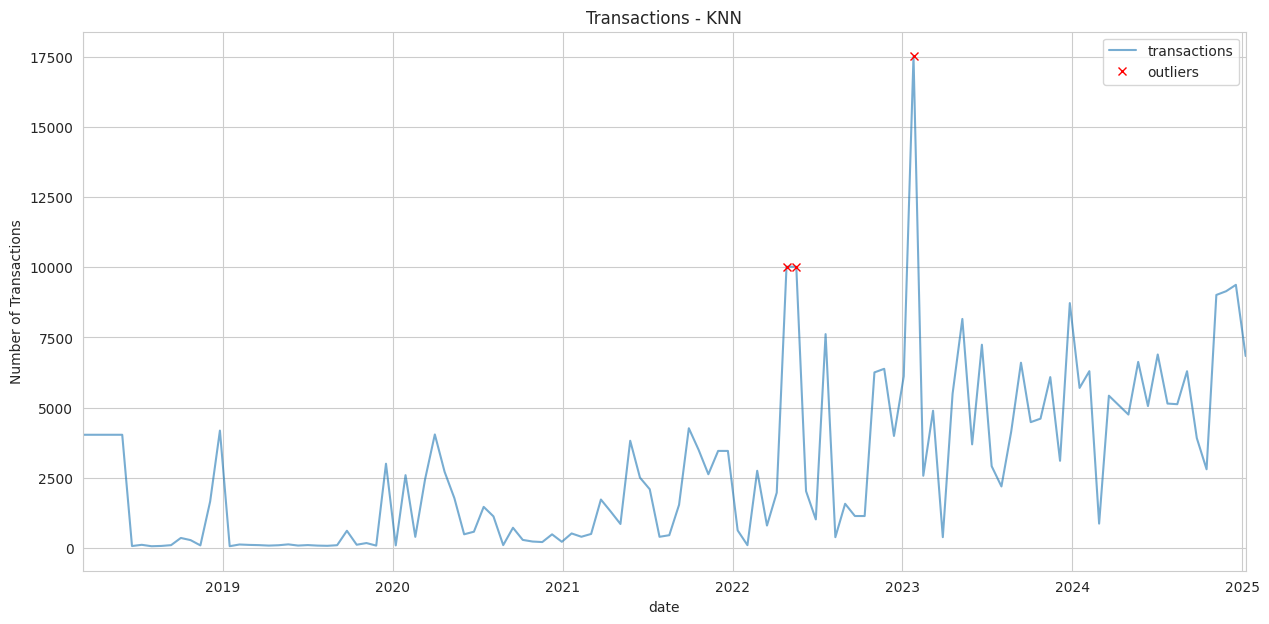

In [53]:
plot_outliers(outliers, transaction_df, 'KNN')

In [65]:
class DifferentOutlierDetectors:
    def __init__(self, df):
        self.df = df
        self.models = {}
        self.fitted_models = {}

    def instantiate_model(self, model_name, **kwargs):
        """
        Dynamically instantiate an outlier detection model.
        
        Args:
            model_name (str): Name of the model to instantiate (e.g., 'KNN', 'LOF', etc.).
            kwargs: Additional parameters to pass to the model constructor.
        
        Raises:
            ValueError: If the model name is not recognized.
        """
        model_mapping = {
            'KNN': KNN,
            'LOF': LOF,
            'CBLOF': CBLOF,
            'IForest': IForest,
            'COPOD': COPOD,
            'MAD': MAD,  # Placeholder for a custom implementation
            'OCSVM': OCSVM,
        }

        if model_name not in model_mapping:
            raise ValueError(f"Model '{model_name}' is not recognized. Available models: {list(model_mapping.keys())}")
        
        model_class = model_mapping[model_name]
        if model_class is None:
            raise NotImplementedError(f"The model '{model_name}' is not yet implemented.")
        
        # Instantiate the model with provided parameters
        model = model_class(**kwargs)
        self.models[model_name] = model
        return model
    
    def fit(self, model_name, X):
        """
        Fit the specified model to the data.
        
        Args:
            model_name (str): Name of the model to fit.
            X (array-like): Input features for fitting the model.
        """
        if model_name not in self.models:
            raise ValueError(f"Model '{model_name}' has not been instantiated. Call 'instantiate_model' first.")
        
        model = self.models[model_name]
        model.fit(X)
        self.fitted_models[model_name] = model

    def predict(self, model_name, X):
        """
        Predict outliers using the specified model.
        
        Args:
            model_name (str): Name of the model to use for predictions.
            X (array-like): Input features for prediction.
        
        Returns:
            np.ndarray: Binary labels for outliers (1 for outlier, 0 for inlier).
        """
        if model_name not in self.fitted_models:
            raise ValueError(f"Model '{model_name}' has not been fitted. Call 'fit' first.")
        
        model = self.fitted_models[model_name]
        predicted = model.predict(X)
        return predicted
    
    def plot_outliers(self, outliers, df, model_name='KNN', halignment='right', valignment='bottom', labels=False):
        """
        Plots outliers on a time-series-like plot.
        
        Parameters:
        outliers: DataFrame containing known outliers.
        df: DataFrame to check and plot the outliers.
        method: String, the name of the method used for detection.
        halignment: Horizontal alignment for labels.
        valignment: Vertical alignment for labels.
        labels: Boolean, whether to display labels for outliers.
        """
        ax = df.plot(alpha=0.6)

        if labels:
            for i in outliers['value'].items():
                plt.plot(i[0], i[1], 'rx', markersize=8, markerfacecolor='none', markeredgecolor='k')
                plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
        else:
            df.loc[outliers.index].plot(ax=ax, style='rx')

        plt.title(f'Transactions - {model_name}')
        plt.xlabel('Date')
        plt.ylabel('Number of Transactions')
        plt.legend(['Transactions', 'Outliers'])
        plt.show()

In [ ]:
outlier_detector = DifferentOutlierDetectors(transaction_df)

outlier_detector.instantiate_model('LOF', contamination=0.09, n_neighbors=10)
outlier_detector.fit('LOF', transaction_df.values)

predicted = outlier_detector.predict('LOF', transaction_df.values)

outliers = transaction_df[predicted == 1]
# outliers = transaction_df.loc[outliers.index]
outliers

,Amount
Transaction_Date,
2019-05-22,126.176471
2019-11-06,172.915254
2020-10-28,227.082192
2020-11-18,208.338308
2020-12-30,217.490190
2022-04-27,10022.400000
2022-05-18,10022.400000
2023-01-25,17522.400000


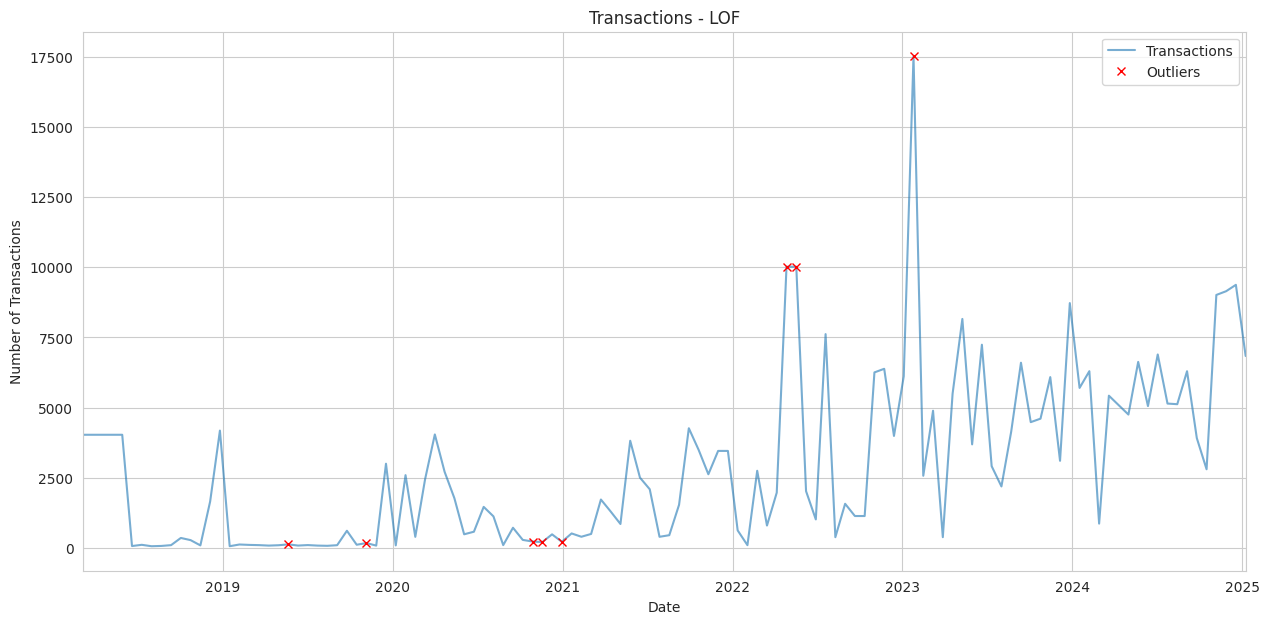

In [69]:
outlier_detector.plot_outliers(outliers, transaction_df, 'LOF')

In [70]:
outlier_detector = DifferentOutlierDetectors(transaction_df)

outlier_detector.instantiate_model('CBLOF', n_clusters=10, contamination=0.09)
outlier_detector.fit('CBLOF', transaction_df.values)

predicted = outlier_detector.predict('CBLOF', transaction_df.values)

outliers = transaction_df[predicted == 1]
outliers

,Amount
Transaction_Date,
2022-04-27,10022.400000
2022-05-18,10022.400000
2022-07-20,7618.835000
2023-01-25,17522.400000
2023-05-10,8159.984000
2023-06-21,7241.225730
2023-12-27,8724.560606
2024-01-17,5701.791429
2024-11-06,9014.925128


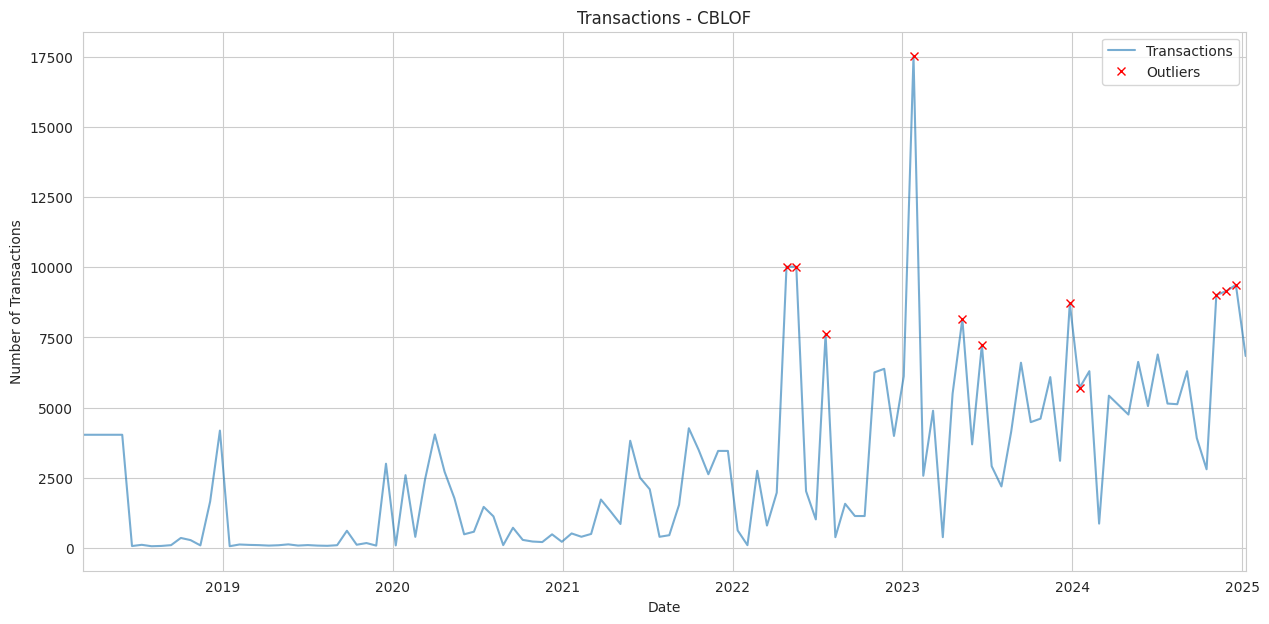

In [71]:
outlier_detector.plot_outliers(outliers, transaction_df, 'CBLOF')

### Exploratory Data Analysis

In [ ]:
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    # from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

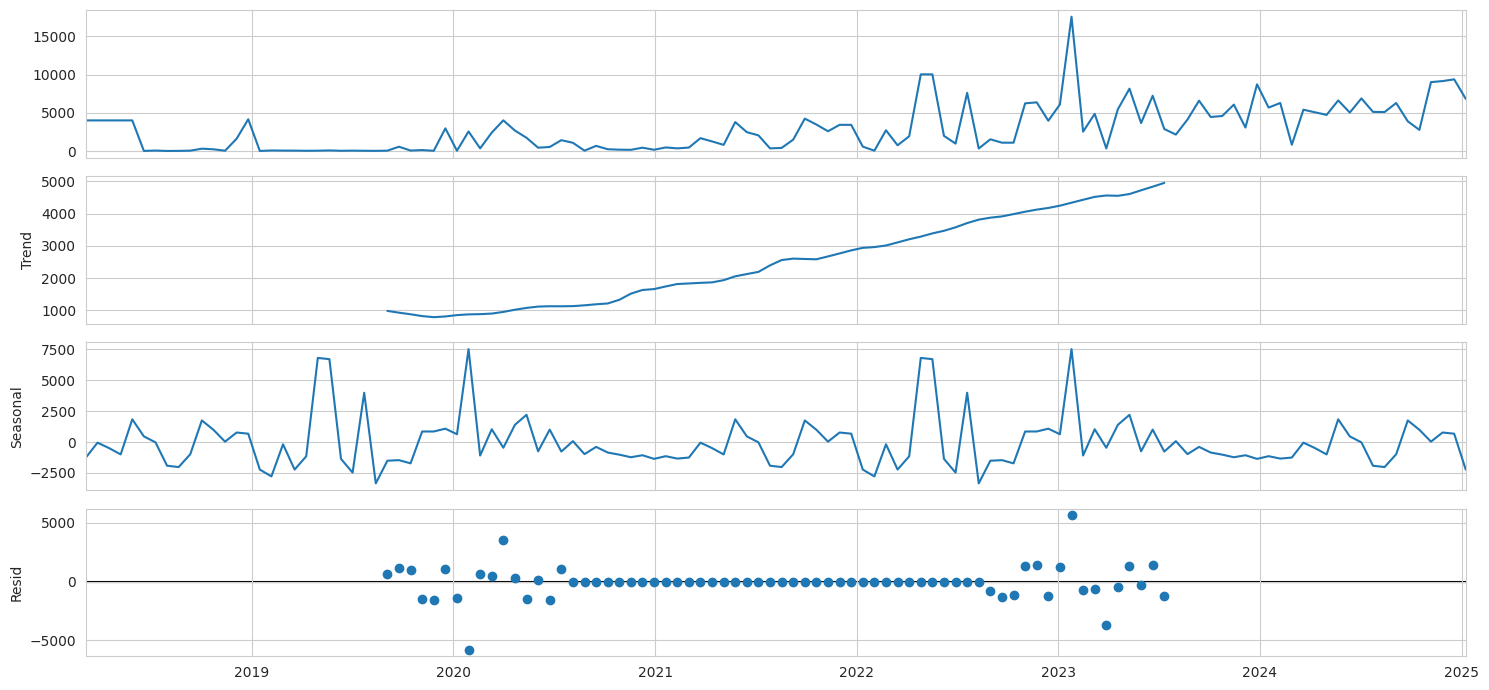

In [74]:
transaction_decomposed = seasonal_decompose(transaction_df, model='additive')

transaction_decomposed.plot(); plt.show()

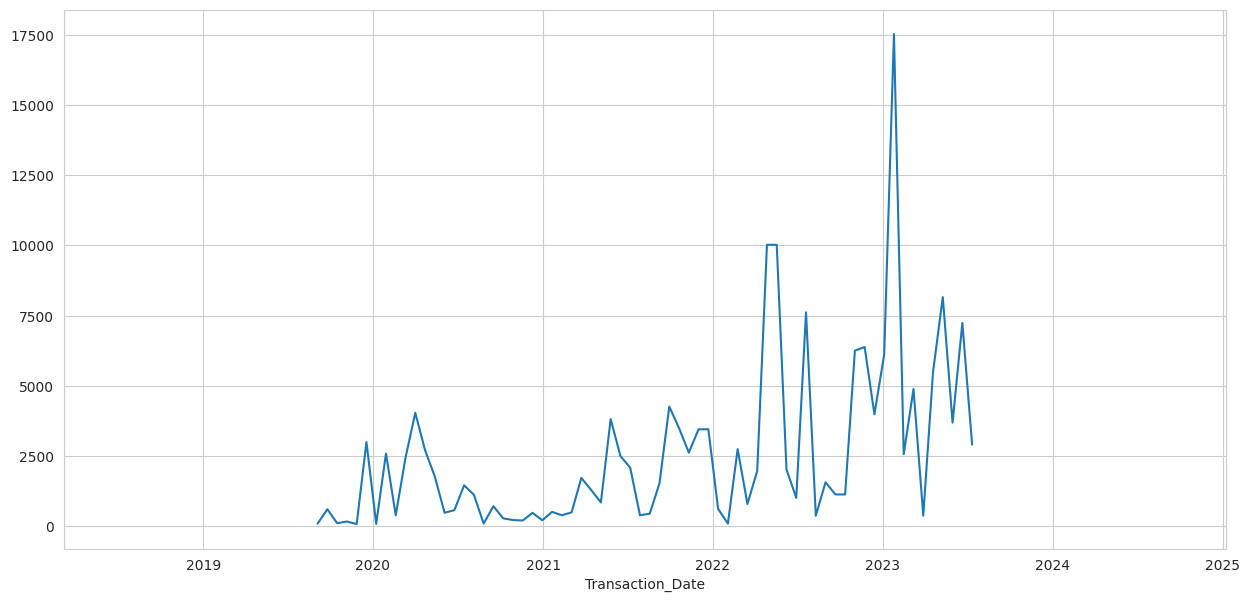

In [75]:
(transaction_decomposed.trend + transaction_decomposed.seasonal + transaction_decomposed.resid).plot()
plt.show()

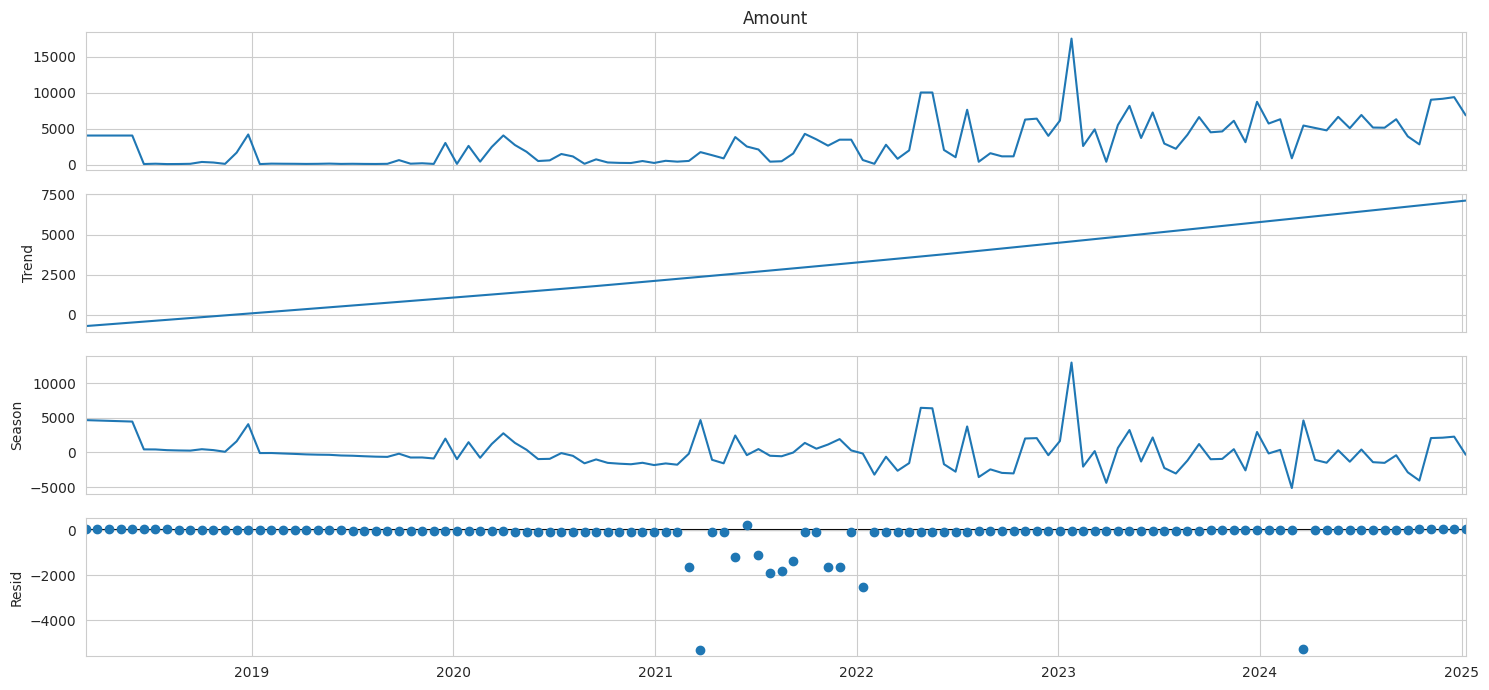

In [76]:
transaction_stl = STL(transaction_df['Amount'], seasonal=13, robust=True).fit()

transaction_stl.plot(); plt.show()

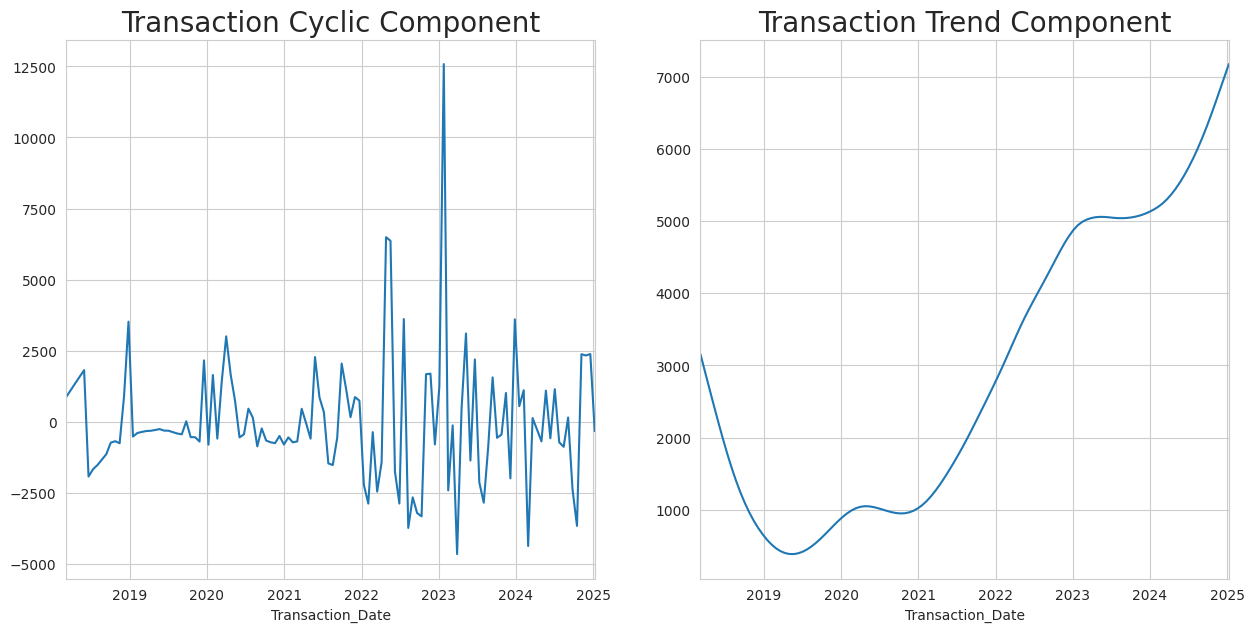

In [79]:
transaction_cyclic, transaction_trend = hpfilter(transaction_df)

fig, ax = plt.subplots(1, 2)
transaction_cyclic.plot(ax=ax[0], title="Transaction Cyclic Component")
transaction_trend.plot(ax=ax[1], title="Transaction Trend Component")
ax[0].title.set_size(20); ax[1].title.set_size(20)

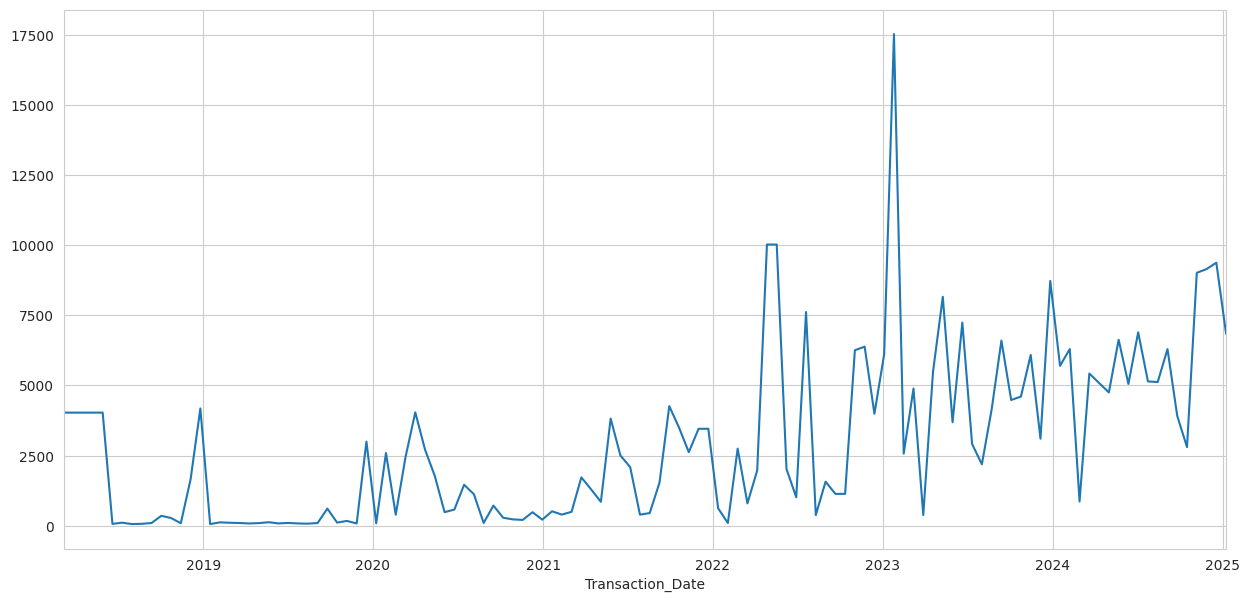

In [80]:
(transaction_cyclic + transaction_trend).plot(); plt.show()

### Detecting Stationarity

Hypothesis Formation:

    H0: The time series is non-stationary if the p-value is greater than 0.05, thus accepting the null hypothesis.
    H1: The time series is stationary if the p-value is less than 0.05, thus rejecting the null hypothesis.

In [82]:
# Create a function that outputs the results in a user-friendly way.
def print_results(output, test):
    '''
    output: 
    test: the type of test, 'adf','kpss'
    '''
    p_value = output[1]
    test_score = output[0]
    lags = output[2]
    decision = 'Non-stationary'

    critical = []
    if test == 'adf':
        critical = output[4]
        if p_value < 0.05:
            decision = 'Stationary'
    elif test == 'kpss':
        critical = output[3]
        if p_value >= 0.05:
            decision = 'Stationary'
    
    output_dict = {
        'Test_Statistic': test_score,
        'p-value': p_value,
        'Numbers of Lags': lags,
        'decision': decision
    }

    for key, value in critical.items():
        output_dict["Critical Value {%s}" % key] = value

    return pd.Series(output_dict, name=test)

In [83]:
adf_output = adfuller(transaction_df)
kpss_output = kpss(transaction_df)

In [85]:
pd.concat([
    print_results(adf_output, 'adf'),
    print_results(kpss_output, 'kpss')
], axis=1)

,adf,kpss
Test_Statistic,-0.110422,1.539224
p-value,0.94839,0.01
Numbers of Lags,10,5
decision,Non-stationary,Non-stationary
Critical Value {1%},-3.491818,0.739
Critical Value {5%},-2.888444,0.463
Critical Value {10%},-2.58112,0.347
Critical Value {2.5%},NaN,0.574


To interpret the output of the results, for ADF we can see the decision is Non-stationary supported by a higher p-value of 0.94 which is greater than 0.05, therefore, accept the null hypothesis that the time series is Non-stationary. For KPSS, the time series is Non-stationary as per the decision, also it's p-value is less than 0.05, thus rejecting the null hypothesis that the time series is Non-stationary.

In [86]:
def check_stationarity(df):
    adf_test = adfuller(df)
    kpss_test = kpss(df)

    adf_pvalue, kpss_pvalue = adf_test[1], kpss_test[1]
    kpssh, adfh = 'Stationary', 'Non-stationary'

    if adf_pvalue < 0.05:
        adfh = 'Stationary'

    if kpss_pvalue < 0.05:
        kpssh = 'Non-stationary'

    return (kpssh, adfh)

In [99]:
def plot_comparison(methods, plot_type='line'):
    n = len(methods) // 2
    fig, ax = plt.subplots(n, 2, sharex=True, figsize=(20,10))
    for i, method in enumerate(methods):
        method.dropna(inplace=True)
        name = [n for n in globals() if globals() [n] is method]
        v, r = i // 2, i % 2

        kpss_stnd, adf_stnd = check_stationarity(method)

        method.plot(
            kind=plot_type, ax=ax[v,r], legend=False,
            title=f"{name[0]} --> KPSS: {kpss_stnd}, ADF: {adf_stnd}"
        )
        ax[v,r].title.set_size(20)
        method.rolling(window=52).mean().plot(ax=ax[v,r], legend=False)  # subtracting moving average with rolling window of 52. use diff() for differencing

In [100]:
first_order_diff = transaction_df.diff().dropna()
differencing_twice = transaction_df.diff(52).diff().dropna()
rolling = transaction_df.rolling(window=52).mean()
subtract_rolling_mean = transaction_df - rolling
log_transform = np.log(transaction_df)
decomp = seasonal_decompose(transaction_df)
sd_detrend = decomp.observed - decomp.trend
cyclic, trend = hpfilter(transaction_df)

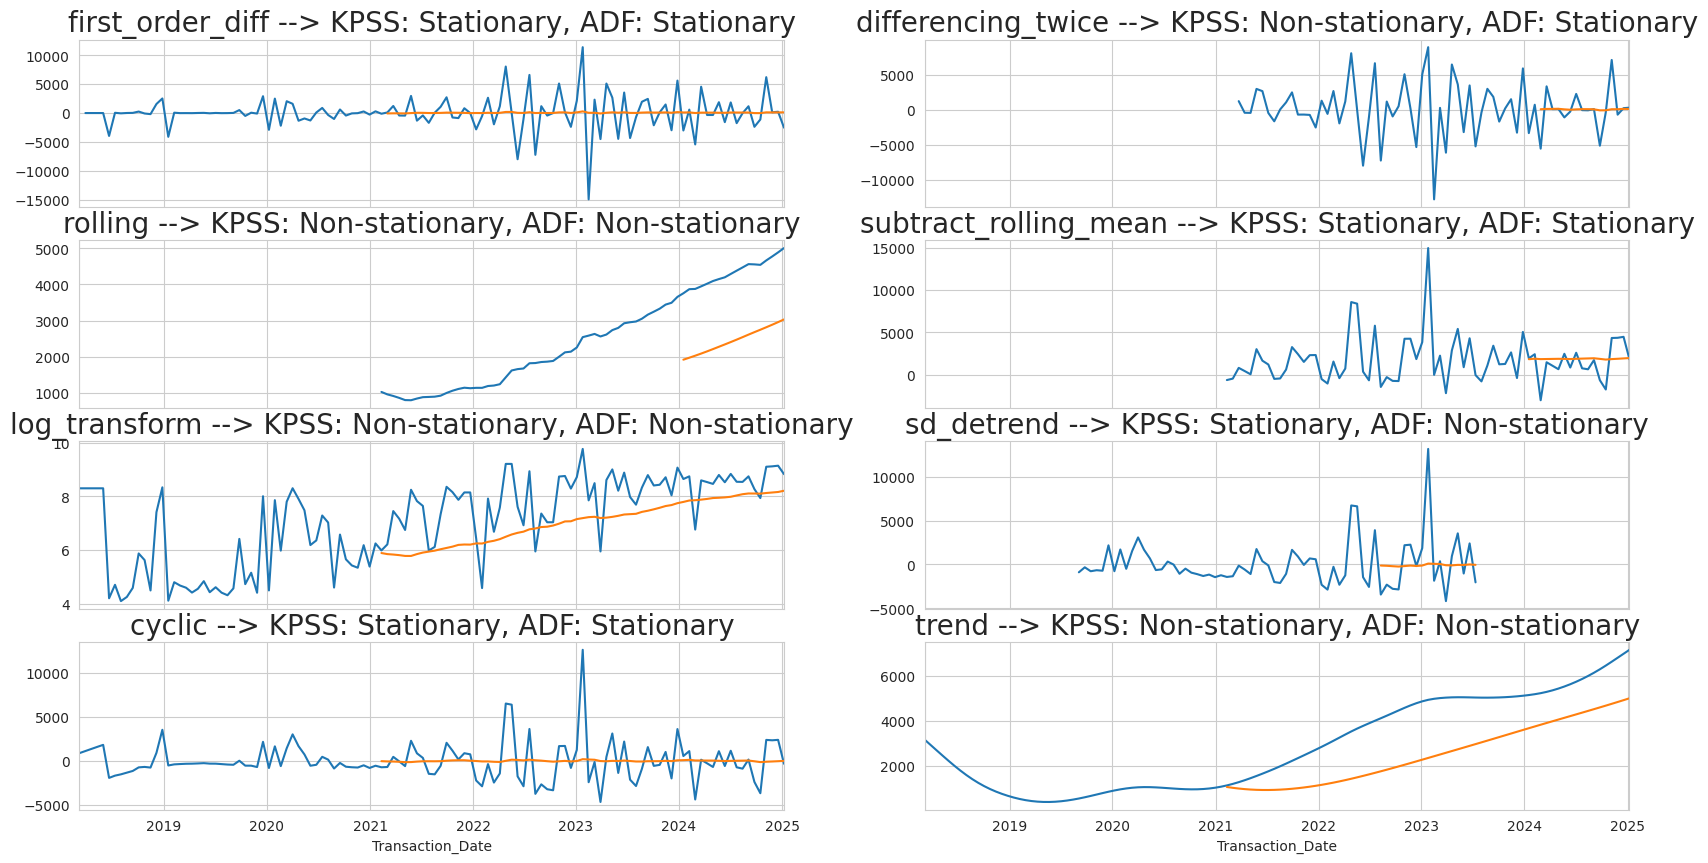

In [101]:
methods = [first_order_diff, differencing_twice, rolling, subtract_rolling_mean, log_transform, sd_detrend, cyclic, trend]

plot_comparison(methods)

In [102]:
adf_result = adfuller(first_order_diff, store=True)

adf_result[-1].resols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     39.65
Date:                Tue, 28 Jan 2025   Prob (F-statistic):           4.46e-30
Time:                        13:36:33   Log-Likelihood:                -997.99
No. Observations:                 109   AIC:                             2018.
Df Residuals:                      98   BIC:                             2048.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -6.1282      0.960     -6.387      0.000      -8.032      -4.224
x2             4.3810      0.912      4.805      0.000       2.571       6.191
x3             3.6151      0.832      4.346      0.000       1.964       5.266
x4             2.9434      0.738      3.987      0.000       1.478       4.408
x5             2.3600      0.631      3.737      0.000       1.107       3.613
x6             1.8203      0.525      3.471      0.001       0.779       2.861
x7             1.2739      0.417      3.055      0.003       0.446       2.101
x8             0.8443      0.306      2.761      0.007       0.238       1.451
x9             0.3652      0.198      1.843      0.068      -0.028       0.758
x10            0.1907      0.100      1.906      0.060      -0.008       0.389
const        302.4135    234.476      1.290      0.200    -162.896     767.723
==============================================================================
Omnibus:                       46.942   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              196.657
Skew:                           1.382   Prob(JB):                     1.98e-43
Kurtosis:                       8.972   Cond. No.                     8.00e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [105]:
kpss_result = kpss(first_order_diff, store=True)

kpss_result

(0.3471725880816122,
 0.09992560858551197,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 <statsmodels.stats.diagnostic.ResultsStore at 0x70b215933800>)

In [110]:
model = AutoReg(transaction_df.dropna(), lags=1, trend='n').fit()

In [111]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                 Amount   No. Observations:                  120
Model:                     AutoReg(1)   Log Likelihood               -1112.352
Method:               Conditional MLE   S.D. of innovations           2775.416
Date:                Tue, 28 Jan 2025   AIC                           2228.704
Time:                        13:56:00   BIC                           2234.262
Sample:                    03-28-2018   HQIC                          2230.961
                         - 01-08-2025                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Amount.L1      0.7522      0.061     12.244      0.000       0.632       0.873
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.3294           +0.0000j            1.3294            0.0000
-----------------------------------------------------------------------------
"""

### Test for Normality

In [107]:
def is_normal(test, p_value=0.05):
    stat, p_value = test

    return 'Normal' if p_value > 0.05 else 'Not Normal'

In [108]:
normal_args = (np.mean(transaction_df),np.std(transaction_df))

# Normality tests
print(is_normal(shapiro(transaction_df)))     # Shapiro-Wilk Test
print(is_normal(normaltest(transaction_df)))   # D'Agostino-Pearson
# print(is_normal(normal_ad(transaction_df)))
print(is_normal(kstest_normal(transaction_df)))    # Kolmogorov-Smirnov Test
print(is_normal(kstest(transaction_df, cdf='norm',args=normal_args)))   # Kolmogorov-Smirnov Test

Not Normal
Not Normal
Not Normal
Not Normal


(array([ 1.,  0.,  3., 10., 66., 29.,  5.,  3.,  1.,  1.]),
 array([-10609.17178648,  -8255.99058258,  -5902.80937867,  -3549.62817477,
         -1196.44697086,   1156.73423304,   3509.91543695,   5863.09664085,
          8216.27784475,  10569.45904866,  12922.64025256]),
 <BarContainer object of 10 artists>)

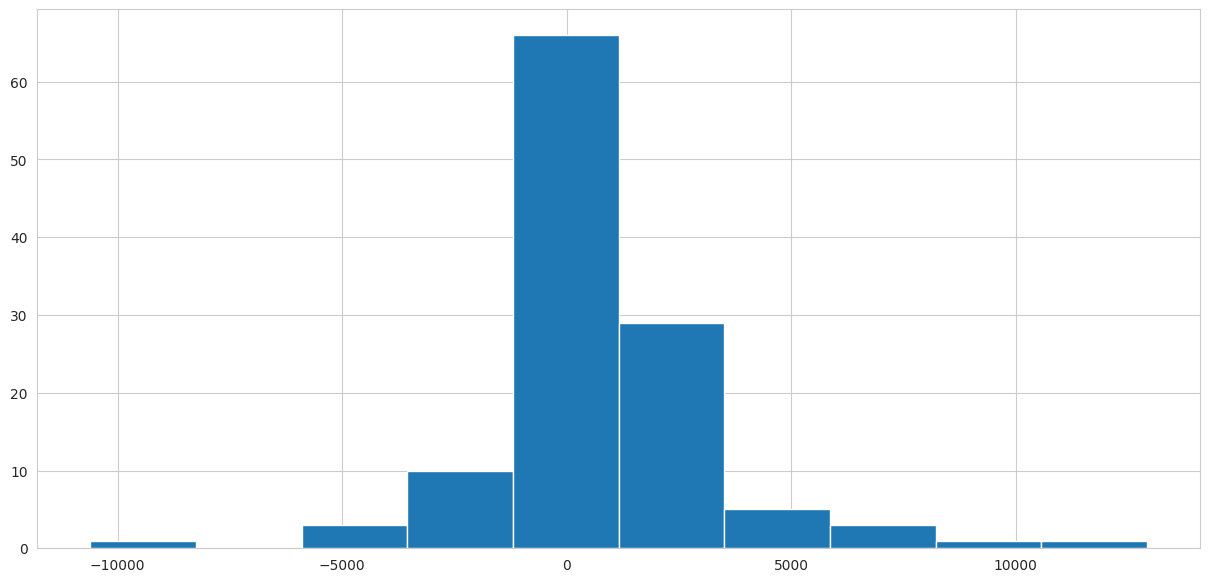

In [112]:
plt.hist(model.resid)

In [113]:
shapiro(model.resid)

ShapiroResult(statistic=0.8768708053445772, pvalue=1.691126982281705e-08)

In [114]:
model.resid.mean()

731.1242596133474

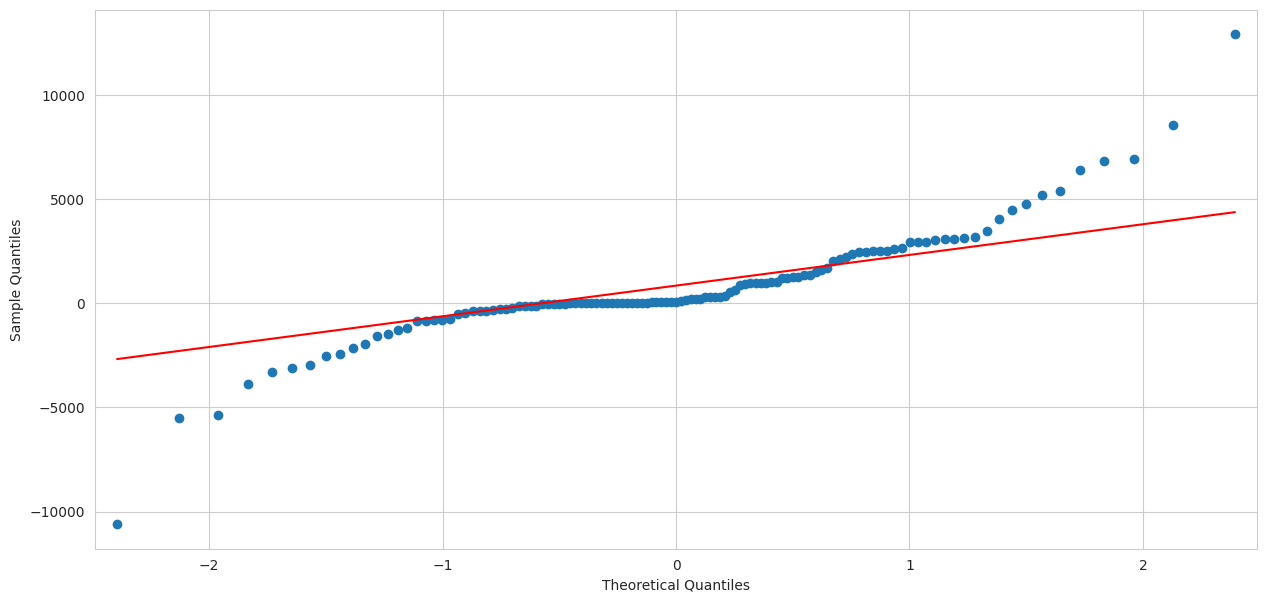

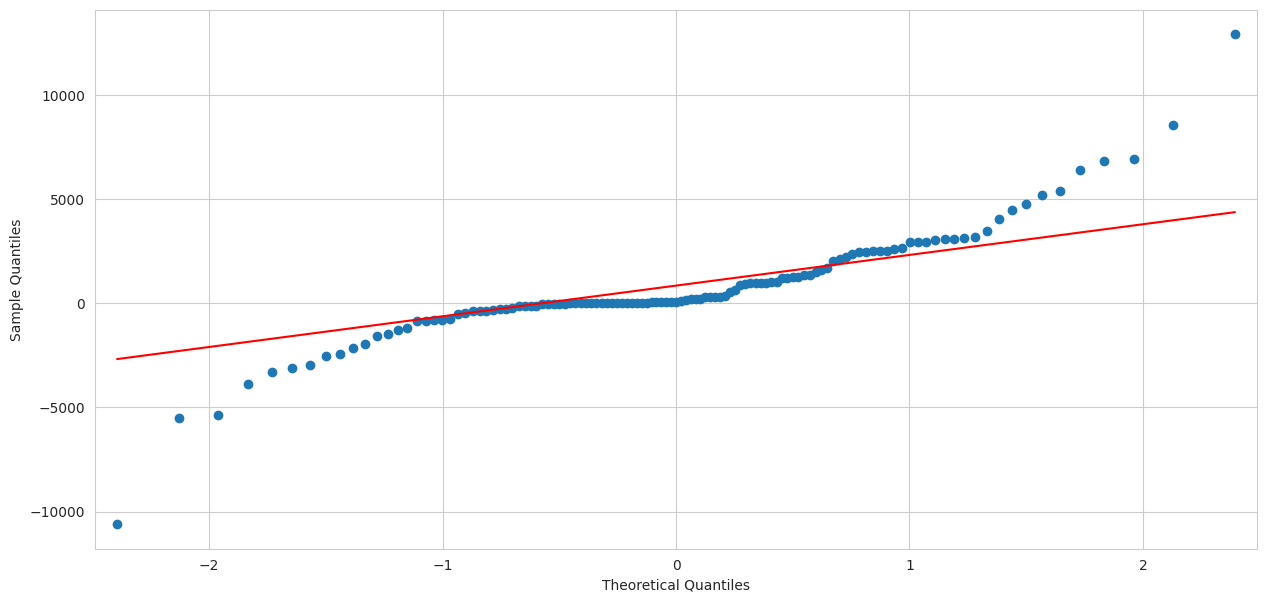

In [115]:
qqplot(model.resid, line='q')

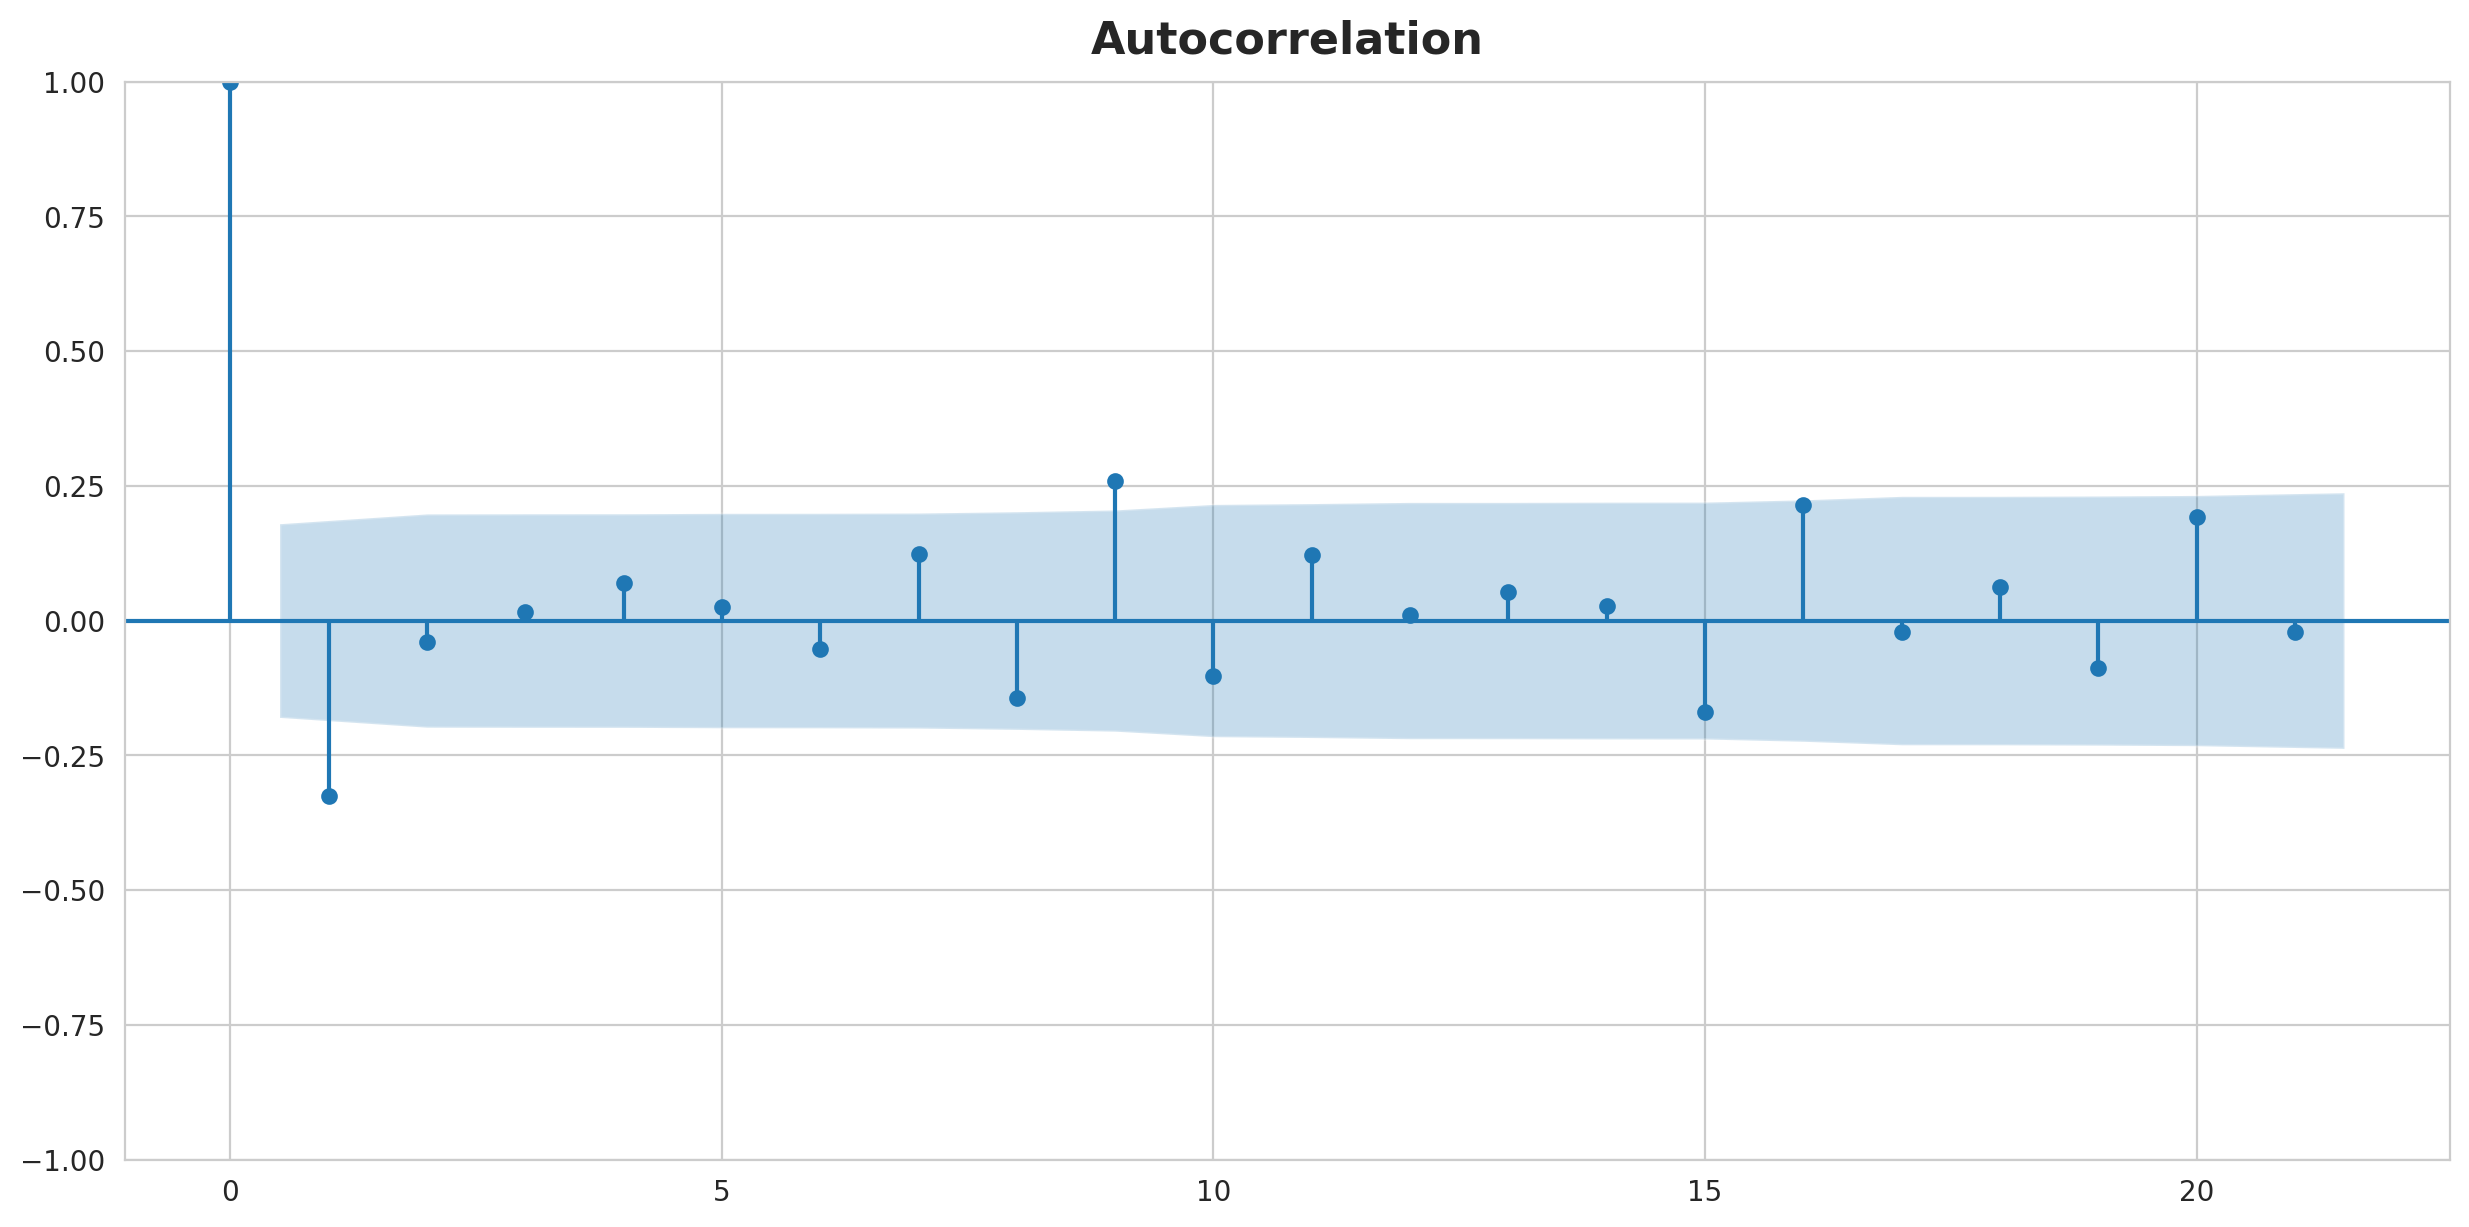

In [119]:
plot_acf(model.resid); plt.show()

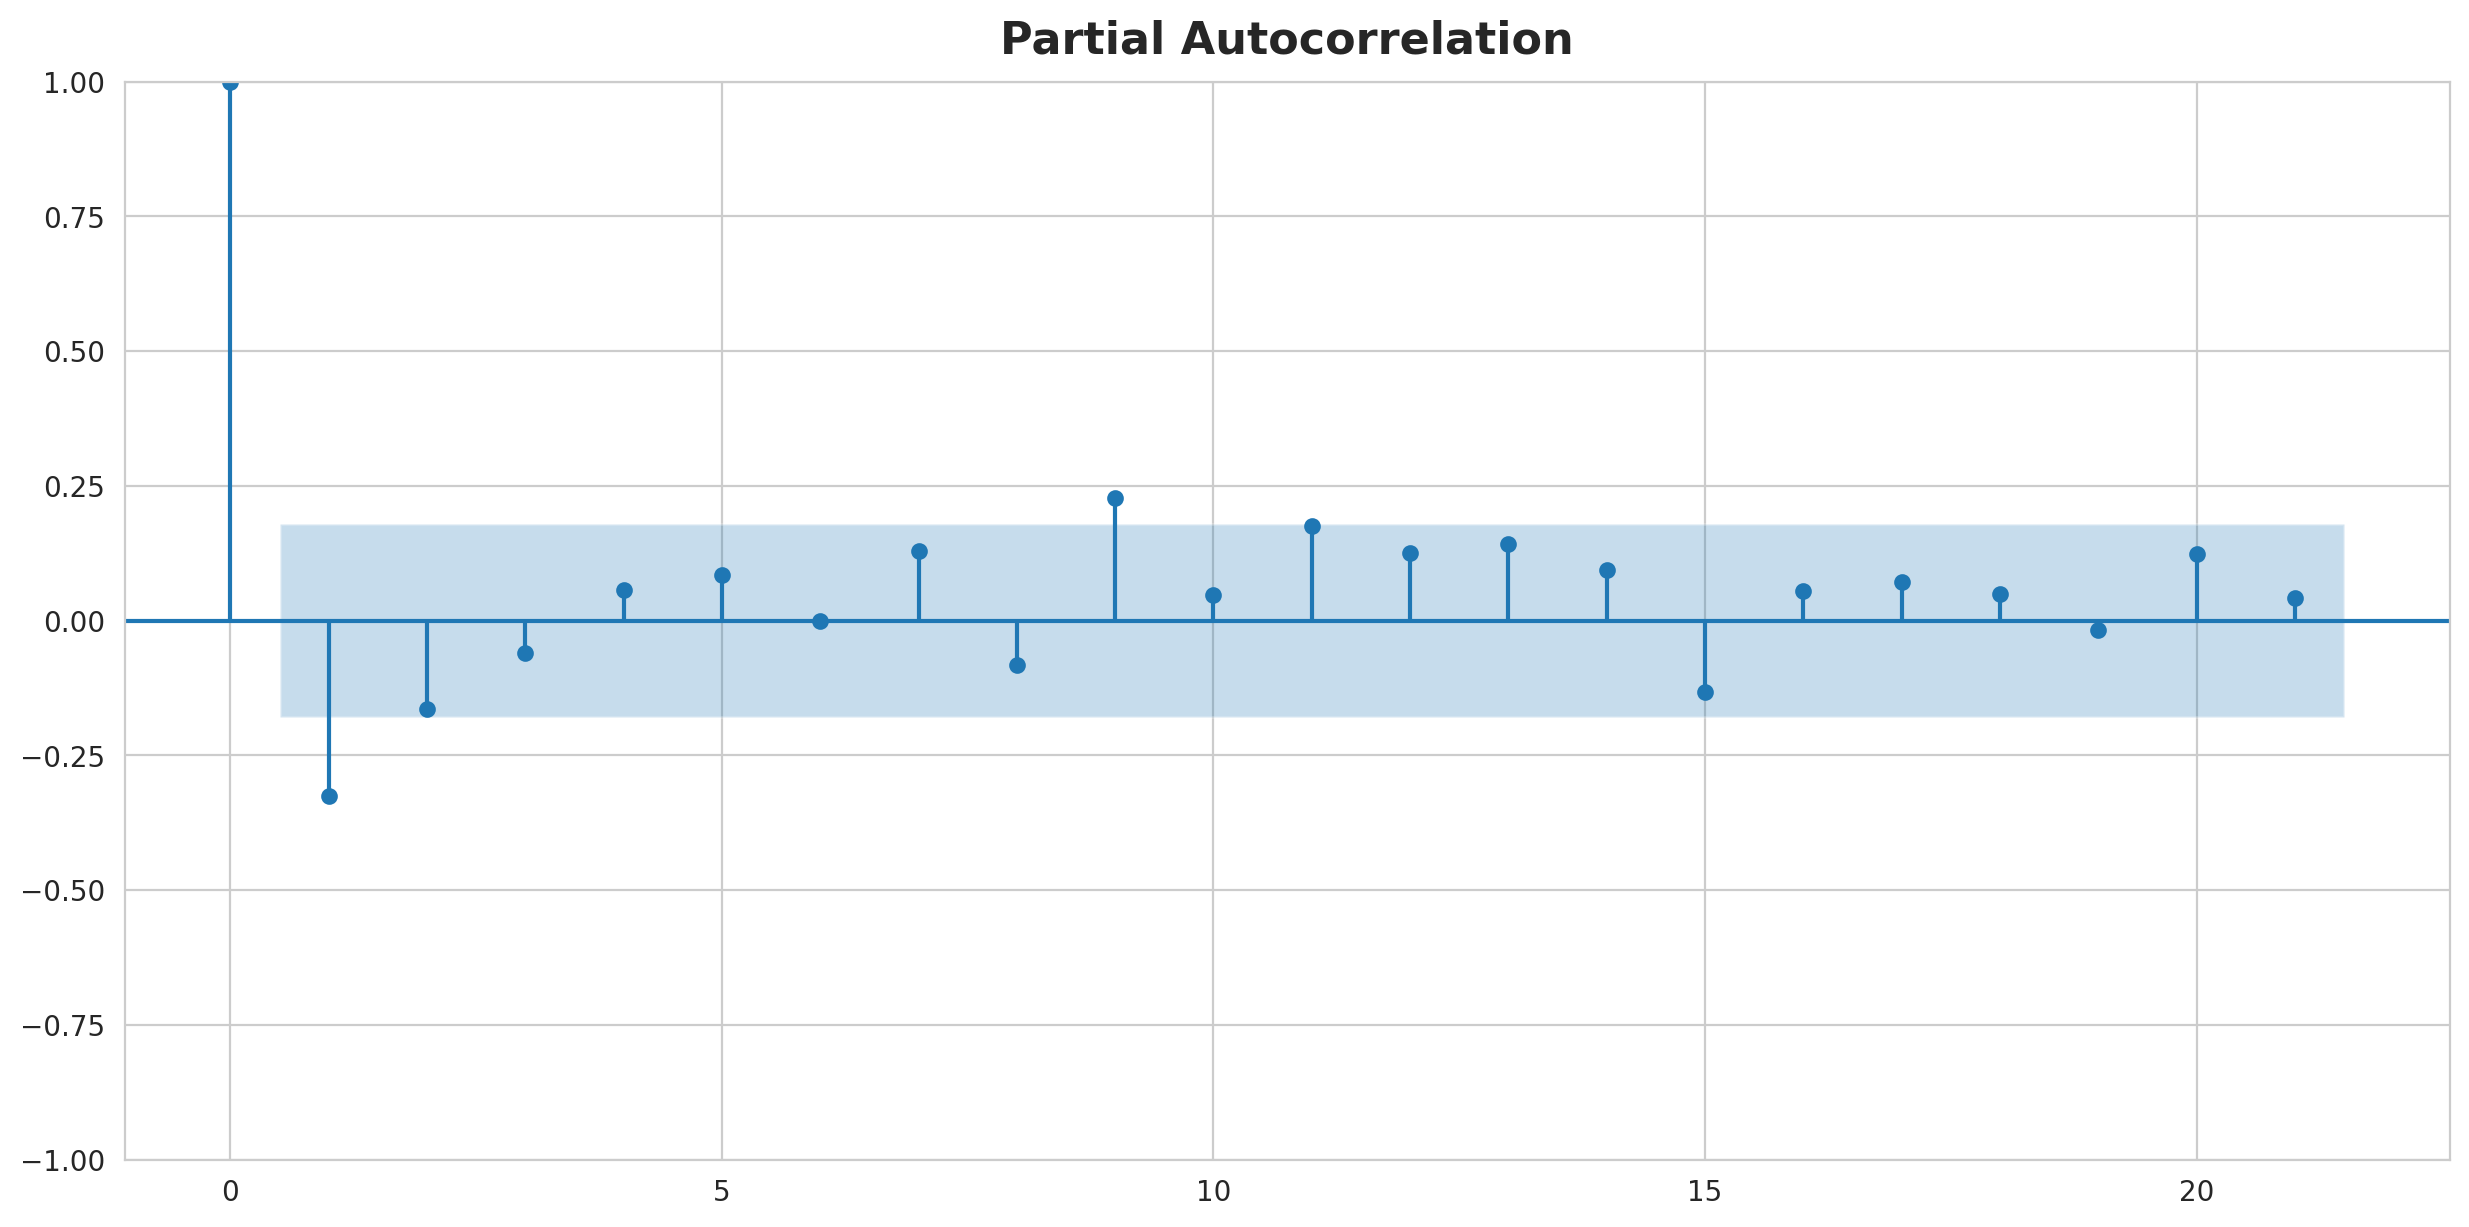

In [120]:
plot_pacf(model.resid); plt.show()

MA(1)

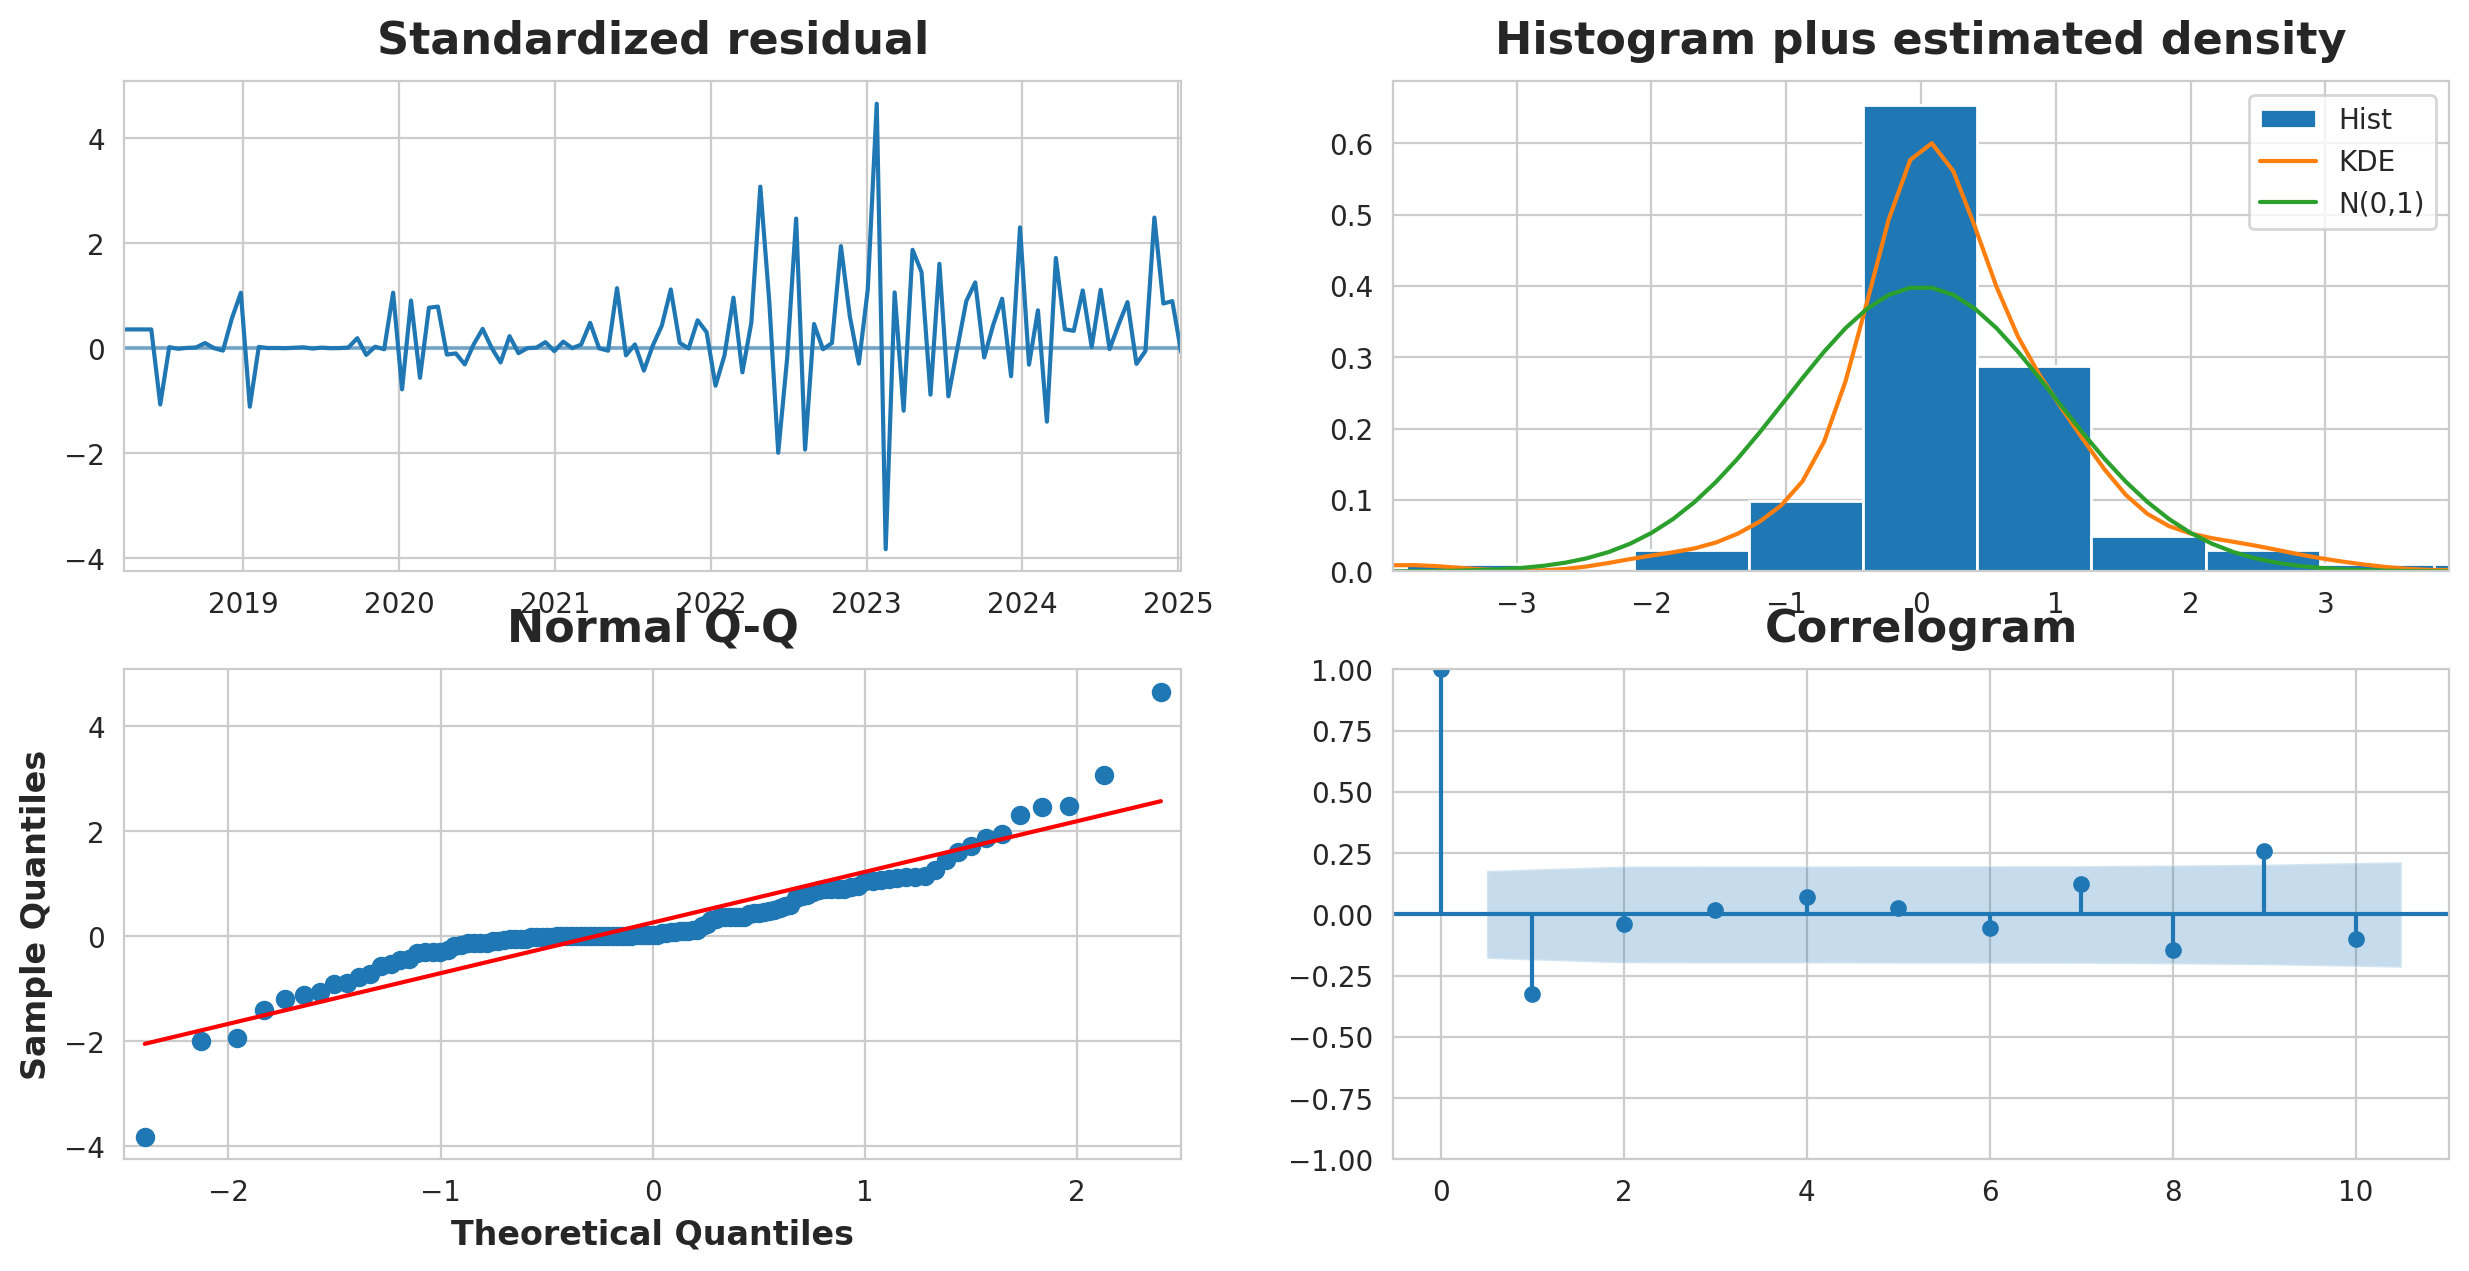

In [121]:
model.plot_diagnostics(); plt.show()

### Testing Homoscedasticity

In [122]:
model = AutoReg(transaction_df.ffill(), lags=1).fit()

print(is_normal(shapiro(model.resid)))

Not Normal


In [123]:
model.test_normality()

Jarque-Bera    1.628871e+02
P-value        4.261092e-36
Skewness       1.315562e+00
Kurtosis       8.091990e+00
dtype: float64

In [124]:
model.test_heteroskedasticity()

,ARCH-LM,P-value,DF
Lag,,,
1,8.978724,0.002731,1
2,9.224352,0.009930,2
3,9.391199,0.024517,3
4,11.677317,0.019919,4
5,11.686979,0.039338,5
6,11.943647,0.063238,6
7,11.889300,0.104259,7
8,11.830243,0.158940,8
9,13.240941,0.152004,9


In [127]:
def het_test(model, test=""):
    '''
    model: model for testing heteroscedasticity
    test: the type of test to be used for normality
    '''
    lm, lm_p_value, f_value, f_p_value = (
        test(model.resid, sm.add_constant(model.fittedvalues))
    )

    return "Heteroscedastic" if f_p_value < 0.05 else "Homoscedastic"

In [131]:
het_test(model, test=het_breuschpagan)

'Heteroscedastic'

In [132]:
het_test(model, test=het_white)

'Heteroscedastic'

Therefore, we se see the model to be heteroscedastic with non-constant variance.

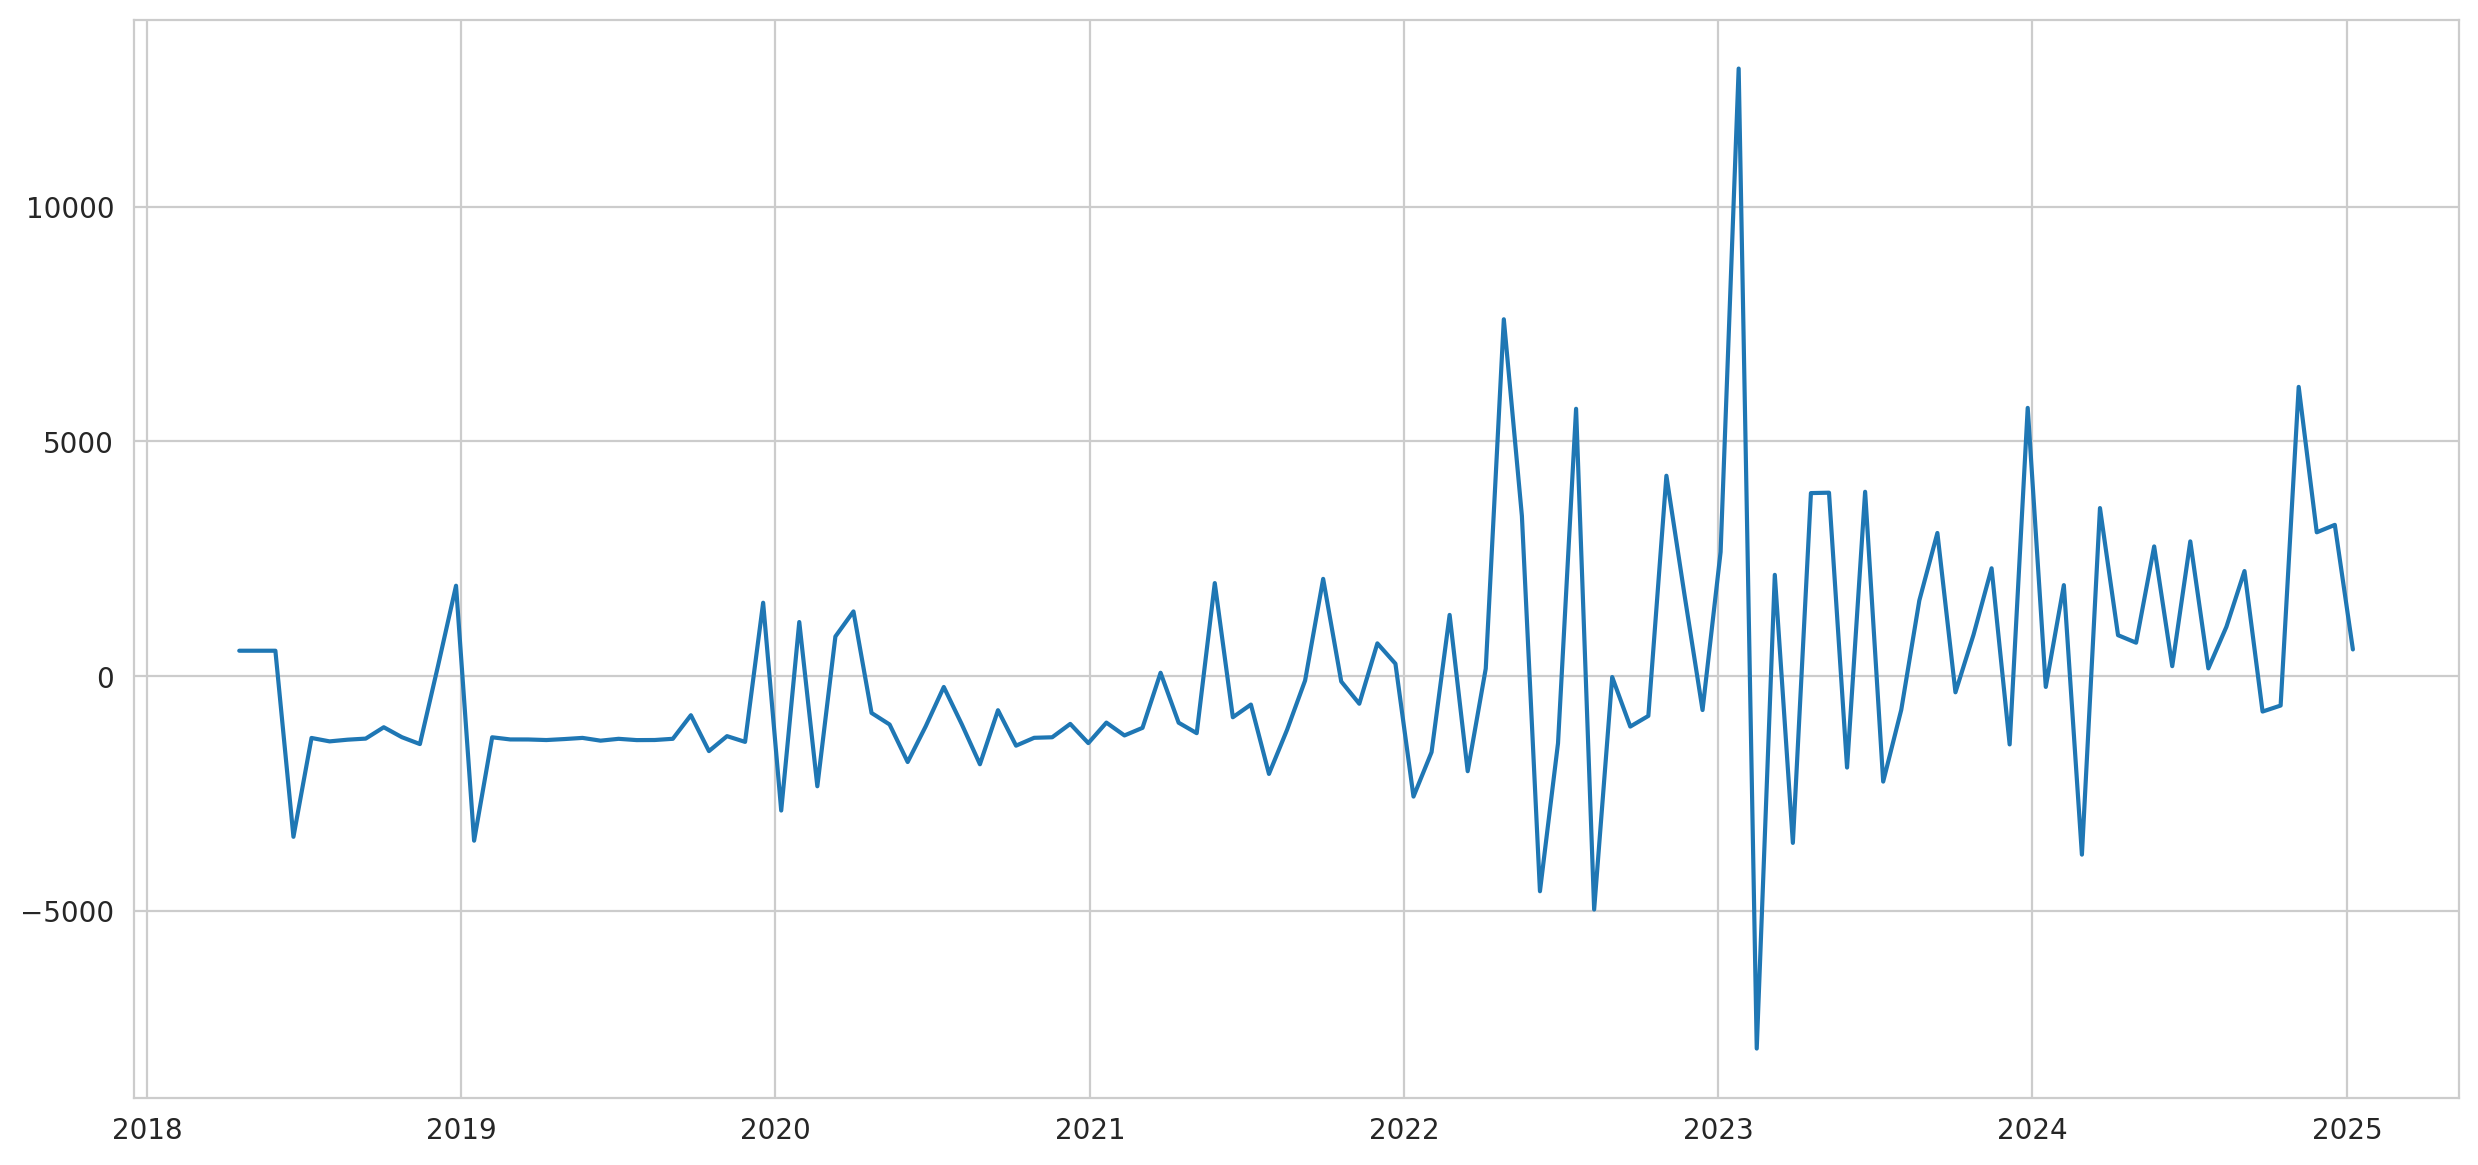

In [135]:
plt.plot(model.resid[1:])

### Testing Autocorrelation

In [137]:
transaction_diff = np.log(transaction_df).diff().dropna()

The null hypothesis for the Ljung-Box test states that the previous lags are not correlated with the current period. In other words, you are testing for the absence of autocorrelation. 

In [139]:
acorr_ljungbox(transaction_diff, lags=10, return_df=True)

,lb_stat,lb_pvalue
1,25.208168,5.146378e-07
2,25.658377,2.681354e-06
3,25.982624,9.617635e-06
4,27.044162,1.947438e-05
5,30.029241,1.455441e-05
6,30.046323,3.851931e-05
7,30.292892,8.390202e-05
8,32.073367,9.036503e-05
9,33.681547,1.015588e-04
10,33.683841,2.089052e-04
